In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('DOMensalEstadoDesde1991.csv', sep=';')
df.head()

,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1991,1,657,NaN,15,NaN,NaN,672,162,3051,...,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,3
1,1991,2,732,NaN,17,NaN,NaN,749,175,3421,...,NaN,NaN,NaN,NaN,209,NaN,NaN,NaN,NaN,3
2,1991,3,713,NaN,25,NaN,NaN,738,216,3613,...,NaN,NaN,NaN,NaN,188,NaN,NaN,NaN,NaN,3
3,1991,4,634,NaN,20,NaN,NaN,654,200,3211,...,NaN,NaN,NaN,NaN,140,NaN,NaN,NaN,NaN,3
4,1991,5,650,NaN,20,NaN,NaN,670,146,3051,...,NaN,NaN,NaN,NaN,78,NaN,NaN,NaN,NaN,3


# Análise Exploratória de Dados (EDA) - Dados de Criminalidade

## Introdução
Esta análise tem como objetivo explorar os dados de criminalidade mensal desde 1991, visando preparar os dados para modelos de Machine Learning (Árvore de Decisão, Redes Neurais e SVM). O dataset contém informações sobre diferentes tipos de crimes organizados por ano e mês.

## 1. Importação de Bibliotecas

In [6]:
# Bibliotecas para análise de dados
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Bibliotecas para análise estatística
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera, anderson
import statsmodels.api as sm

# Bibliotecas para pré-processamento e ML
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configurações
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Exploração Inicial dos Dados

In [7]:
# Informações básicas sobre o dataset
print("🔍 INFORMAÇÕES GERAIS DO DATASET")
print("="*50)
print(f"Dimensões do dataset: {df.shape}")
print(f"Número de linhas: {df.shape[0]:,}")
print(f"Número de colunas: {df.shape[1]}")
print(f"Uso de memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*50)

🔍 INFORMAÇÕES GERAIS DO DATASET
Dimensões do dataset: (416, 56)
Número de linhas: 416
Número de colunas: 56
Uso de memória: 0.18 MB



In [8]:
# Visualização das colunas e tipos de dados
print("📊 ESTRUTURA DAS COLUNAS")
print("="*50)
print("\nTipos de dados por coluna:")
print(df.dtypes)
print(f"\nTotal de colunas por tipo:")
print(df.dtypes.value_counts())

# Verificar as primeiras linhas
print("\n📋 PRIMEIRAS 5 LINHAS:")
print("="*50)
display(df.head())

📊 ESTRUTURA DAS COLUNAS

Tipos de dados por coluna:
ano                             int64
mes                             int64
hom_doloso                      int64
lesao_corp_morte              float64
latrocinio                      int64
cvli                          float64
hom_por_interv_policial       float64
letalidade_violenta             int64
tentat_hom                      int64
lesao_corp_dolosa               int64
estupro                       float64
hom_culposo                   float64
lesao_corp_culposa            float64
roubo_transeunte                int64
roubo_celular                 float64
roubo_em_coletivo               int64
roubo_rua                       int64
roubo_veiculo                   int64
roubo_carga                     int64
roubo_comercio                  int64
roubo_residencia                int64
roubo_banco                     int64
roubo_cx_eletronico           float64
roubo_conducao_saque          float64
roubo_apos_saque              float6

,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,estupro,hom_culposo,lesao_corp_culposa,roubo_transeunte,roubo_celular,roubo_em_coletivo,roubo_rua,roubo_veiculo,roubo_carga,roubo_comercio,roubo_residencia,roubo_banco,roubo_cx_eletronico,roubo_conducao_saque,roubo_apos_saque,roubo_bicicleta,outros_roubos,total_roubos,furto_veiculos,furto_transeunte,furto_coletivo,furto_celular,furto_bicicleta,outros_furtos,total_furtos,sequestro,extorsao,sequestro_relampago,estelionato,apreensao_drogas,posse_drogas,trafico_drogas,apreensao_drogas_sem_autor,recuperacao_veiculos,apf,aaapai,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1991,1,657,NaN,15,NaN,NaN,672,162,3051,NaN,NaN,NaN,967,NaN,381,1348,1174,63,350,188,37,NaN,NaN,NaN,NaN,158,3318,2009,1147,NaN,NaN,NaN,3561,6717,NaN,NaN,NaN,NaN,133,NaN,NaN,NaN,872,NaN,NaN,NaN,NaN,NaN,NaN,217,NaN,NaN,NaN,NaN,3
1,1991,2,732,NaN,17,NaN,NaN,749,175,3421,NaN,NaN,NaN,963,NaN,432,1395,1097,64,357,171,35,NaN,NaN,NaN,NaN,142,3261,1850,1066,NaN,NaN,NaN,3309,6225,NaN,NaN,NaN,NaN,127,NaN,NaN,NaN,751,NaN,NaN,NaN,NaN,NaN,NaN,209,NaN,NaN,NaN,NaN,3
2,1991,3,713,NaN,25,NaN,NaN,738,216,3613,NaN,NaN,NaN,963,NaN,422,1385,1265,71,443,191,43,NaN,NaN,NaN,NaN,131,3529,2084,1062,NaN,NaN,NaN,3573,6719,NaN,NaN,NaN,NaN,80,NaN,NaN,NaN,789,NaN,NaN,NaN,NaN,NaN,NaN,188,NaN,NaN,NaN,NaN,3
3,1991,4,634,NaN,20,NaN,NaN,654,200,3211,NaN,NaN,NaN,1186,NaN,354,1540,1415,81,425,199,36,NaN,NaN,NaN,NaN,112,3808,2085,1195,NaN,NaN,NaN,3290,6570,NaN,NaN,NaN,NaN,133,NaN,NaN,NaN,787,NaN,NaN,NaN,NaN,NaN,NaN,140,NaN,NaN,NaN,NaN,3
4,1991,5,650,NaN,20,NaN,NaN,670,146,3051,NaN,NaN,NaN,931,NaN,335,1266,1449,82,553,231,27,NaN,NaN,NaN,NaN,147,3755,2185,723,NaN,NaN,NaN,3546,6454,NaN,NaN,NaN,NaN,163,NaN,NaN,NaN,845,NaN,NaN,NaN,NaN,NaN,NaN,78,NaN,NaN,NaN,NaN,3


In [9]:
# Informações detalhadas sobre o dataset
print("📈 INFORMAÇÕES ESTATÍSTICAS DETALHADAS")
print("="*50)
info_stats = df.info()
print("\n" + "="*50)

📈 INFORMAÇÕES ESTATÍSTICAS DETALHADAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 56 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ano                         416 non-null    int64  
 1   mes                         416 non-null    int64  
 2   hom_doloso                  416 non-null    int64  
 3   lesao_corp_morte            320 non-null    float64
 4   latrocinio                  416 non-null    int64  
 5   cvli                        320 non-null    float64
 6   hom_por_interv_policial     332 non-null    float64
 7   letalidade_violenta         416 non-null    int64  
 8   tentat_hom                  416 non-null    int64  
 9   lesao_corp_dolosa           416 non-null    int64  
 10  estupro                     272 non-null    float64
 11  hom_culposo                 332 non-null    float64
 12  lesao_corp_culposa          320 non-null    float64
 1

### 2.1 Identificação de Valores Ausentes e Inconsistências

In [10]:
# Análise de valores ausentes
print("🚨 ANÁLISE DE VALORES AUSENTES")
print("="*50)

# Contagem de valores nulos por coluna
missing_data = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Criar DataFrame com informações sobre valores ausentes
missing_df = pd.DataFrame({
    'Coluna': missing_data.index,
    'Valores_Ausentes': missing_data.values,
    'Percentual': missing_percentage.values
})

# Filtrar apenas colunas com valores ausentes
missing_df = missing_df[missing_df['Valores_Ausentes'] > 0].sort_values('Valores_Ausentes', ascending=False)

if len(missing_df) > 0:
    print(f"\n🔴 Encontradas {len(missing_df)} colunas com valores ausentes:")
    display(missing_df)
else:
    print("\n✅ Não foram encontrados valores ausentes no dataset!")

print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")
print(f"Percentual total de dados ausentes: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100:.4f}%")

🚨 ANÁLISE DE VALORES AUSENTES

🔴 Encontradas 31 colunas com valores ausentes:


,Coluna,Valores_Ausentes,Percentual
25,roubo_bicicleta,276,66.346154
32,furto_bicicleta,276,66.346154
45,aaapai,180,43.269231
41,trafico_drogas,180,43.269231
42,apreensao_drogas_sem_autor,180,43.269231
44,apf,180,43.269231
40,posse_drogas,180,43.269231
46,cmp,180,43.269231
47,cmba,180,43.269231
31,furto_celular,144,34.615385



Total de valores ausentes: 4512
Percentual total de dados ausentes: 19.3681%


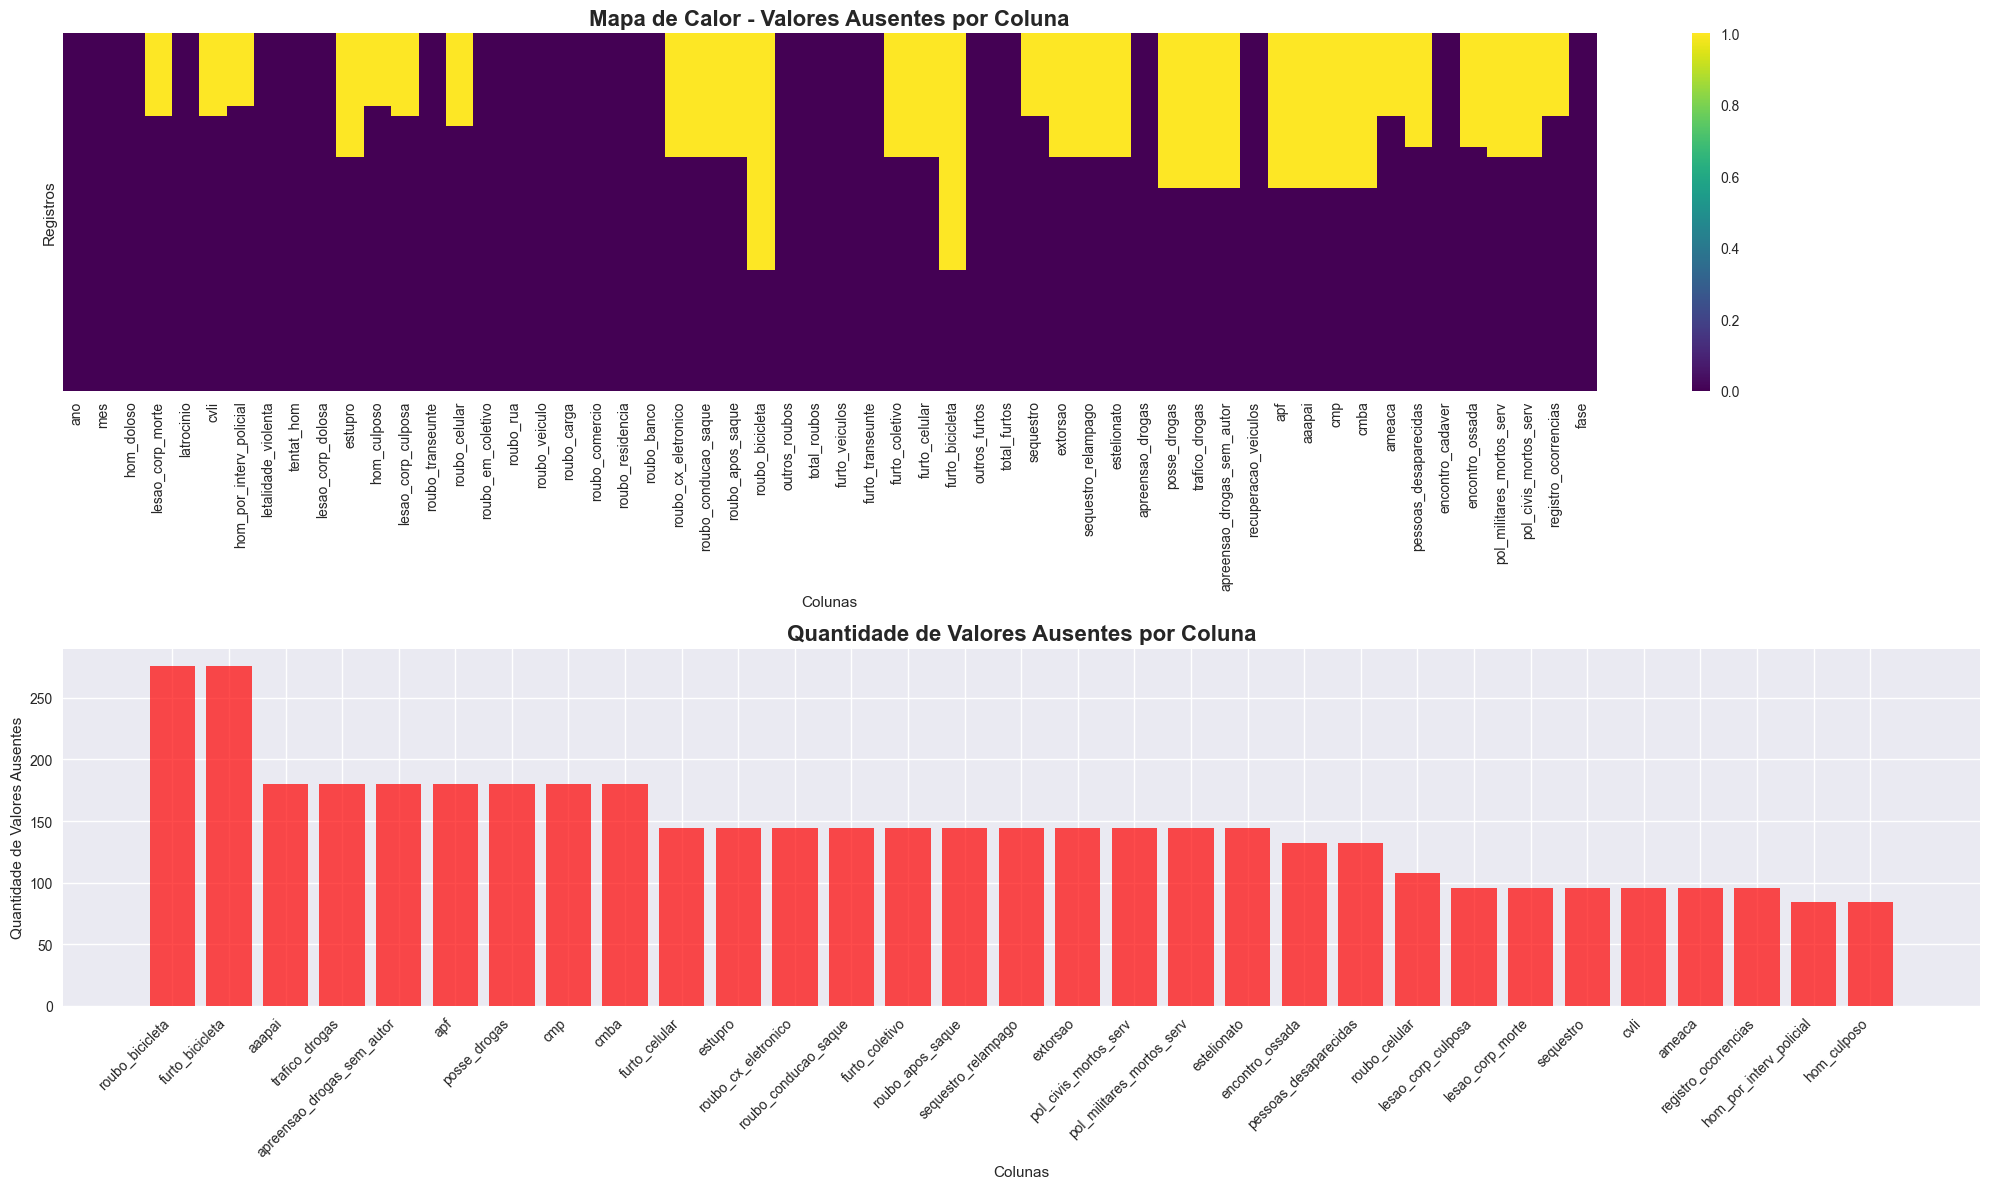

In [11]:
# Visualização de valores ausentes com heatmap
plt.figure(figsize=(20, 12))
plt.subplot(2, 1, 1)

# Mapa de calor dos valores ausentes
missing_matrix = df.isnull()
sns.heatmap(missing_matrix, yticklabels=False, cbar=True, cmap='viridis')
plt.title('Mapa de Calor - Valores Ausentes por Coluna', fontsize=16, fontweight='bold')
plt.xlabel('Colunas')
plt.ylabel('Registros')

# Gráfico de barras dos valores ausentes
plt.subplot(2, 1, 2)
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.bar(range(len(missing_counts)), missing_counts.values, color='red', alpha=0.7)
plt.title('Quantidade de Valores Ausentes por Coluna', fontsize=16, fontweight='bold')
plt.xlabel('Colunas')
plt.ylabel('Quantidade de Valores Ausentes')
plt.xticks(range(len(missing_counts)), missing_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 2.2 Análise das Variáveis e Estrutura dos Dados

In [12]:
# Identificar colunas categóricas e numéricas
print("🔍 ANÁLISE DA ESTRUTURA DAS VARIÁVEIS")
print("="*60)

# Separar colunas por tipo
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"📊 Variáveis Categóricas ({len(categorical_cols)}):")
for i, col in enumerate(categorical_cols, 1):
    unique_vals = df[col].nunique()
    print(f"  {i:2d}. {col:<30} - {unique_vals:4d} valores únicos")

print(f"\n🔢 Variáveis Numéricas ({len(numerical_cols)}):")
for i, col in enumerate(numerical_cols, 1):
    dtype = str(df[col].dtype)
    print(f"  {i:2d}. {col:<30} - {dtype}")

# Análise específica das principais colunas
print(f"\n📈 RESUMO ESTATÍSTICO DAS PRINCIPAIS VARIÁVEIS")
print("="*60)

# Verificar se existe coluna de data/tempo
date_like_cols = [col for col in df.columns if any(word in col.lower() for word in ['data', 'date', 'ano', 'mes', 'year', 'month'])]
if date_like_cols:
    print(f"🗓️  Colunas relacionadas a tempo encontradas: {date_like_cols}")

# Analisar primeiras colunas para entender a estrutura
print(f"\n🔍 Análise das primeiras colunas:")
for col in df.columns[:10]:
    print(f"  • {col}: {df[col].dtype} - {df[col].nunique()} valores únicos")

🔍 ANÁLISE DA ESTRUTURA DAS VARIÁVEIS
📊 Variáveis Categóricas (0):

🔢 Variáveis Numéricas (56):
   1. ano                            - int64
   2. mes                            - int64
   3. hom_doloso                     - int64
   4. lesao_corp_morte               - float64
   5. latrocinio                     - int64
   6. cvli                           - float64
   7. hom_por_interv_policial        - float64
   8. letalidade_violenta            - int64
   9. tentat_hom                     - int64
  10. lesao_corp_dolosa              - int64
  11. estupro                        - float64
  12. hom_culposo                    - float64
  13. lesao_corp_culposa             - float64
  14. roubo_transeunte               - int64
  15. roubo_celular                  - float64
  16. roubo_em_coletivo              - int64
  17. roubo_rua                      - int64
  18. roubo_veiculo                  - int64
  19. roubo_carga                    - int64
  20. roubo_comercio                

In [13]:
# Vamos examinar os nomes das colunas para entender melhor a estrutura
print("🔍 ANÁLISE DETALHADA DAS COLUNAS")
print("="*60)
print("Todas as colunas do dataset:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

# Tentar identificar padrões nas colunas
print(f"\n📊 PADRÕES IDENTIFICADOS:")
print("="*60)

# Verificar se as colunas representam estados ou regiões do Brasil
estados_br = ['AC', 'AL', 'AP', 'AM', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MT', 'MS', 
              'MG', 'PA', 'PB', 'PR', 'PE', 'PI', 'RJ', 'RN', 'RS', 'RO', 'RR', 'SC', 'SP', 'SE', 'TO']

# Verificar quais colunas podem ser estados
possible_states = [col for col in df.columns if any(estado in col.upper() for estado in estados_br)]
print(f"🗺️  Possíveis colunas de estados: {len(possible_states)}")
if len(possible_states) <= 10:  # Se não for muitas, mostrar todas
    for state in possible_states:
        print(f"   • {state}")
else:
    print(f"   • Primeiras 10: {possible_states[:10]}")
    print(f"   • ... e mais {len(possible_states) - 10}")

# Identificar colunas que podem ser variáveis target
target_keywords = ['demanda', 'consumo', 'oxigenio', 'do', 'total']
possible_targets = [col for col in df.columns if any(keyword in col.lower() for keyword in target_keywords)]
print(f"\n🎯 Possíveis variáveis target: {possible_targets[:5] if len(possible_targets) > 5 else possible_targets}")

🔍 ANÁLISE DETALHADA DAS COLUNAS
Todas as colunas do dataset:
 1. ano
 2. mes
 3. hom_doloso
 4. lesao_corp_morte
 5. latrocinio
 6. cvli
 7. hom_por_interv_policial
 8. letalidade_violenta
 9. tentat_hom
10. lesao_corp_dolosa
11. estupro
12. hom_culposo
13. lesao_corp_culposa
14. roubo_transeunte
15. roubo_celular
16. roubo_em_coletivo
17. roubo_rua
18. roubo_veiculo
19. roubo_carga
20. roubo_comercio
21. roubo_residencia
22. roubo_banco
23. roubo_cx_eletronico
24. roubo_conducao_saque
25. roubo_apos_saque
26. roubo_bicicleta
27. outros_roubos
28. total_roubos
29. furto_veiculos
30. furto_transeunte
31. furto_coletivo
32. furto_celular
33. furto_bicicleta
34. outros_furtos
35. total_furtos
36. sequestro
37. extorsao
38. sequestro_relampago
39. estelionato
40. apreensao_drogas
41. posse_drogas
42. trafico_drogas
43. apreensao_drogas_sem_autor
44. recuperacao_veiculos
45. apf
46. aaapai
47. cmp
48. cmba
49. ameaca
50. pessoas_desaparecidas
51. encontro_cadaver
52. encontro_ossada
53. pol

## 3. Estatísticas Descritivas Detalhadas

In [14]:
# Estatísticas descritivas completas
print("📊 ESTATÍSTICAS DESCRITIVAS DETALHADAS")
print("="*70)

# Estatísticas básicas para variáveis numéricas
desc_stats = df.describe()
print("Estatísticas descritivas básicas:")
display(desc_stats)

# Análise temporal
print(f"\n🗓️ ANÁLISE TEMPORAL:")
print("="*50)
print(f"Período dos dados: {df['ano'].min()} - {df['ano'].max()}")
print(f"Total de anos: {df['ano'].nunique()} anos")
print(f"Total de meses únicos: {df['mes'].nunique()} meses")
print(f"Registros por ano:")
anos_count = df['ano'].value_counts().sort_index()
print(anos_count.to_string())

# Identificar principais categorias de crimes
crime_categories = {
    'Crimes Violentos Letais': ['hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli', 'letalidade_violenta'],
    'Crimes contra Pessoa': ['tentat_hom', 'lesao_corp_dolosa', 'estupro', 'ameaca'],
    'Roubos': [col for col in df.columns if 'roubo' in col],
    'Furtos': [col for col in df.columns if 'furto' in col],
    'Drogas': [col for col in df.columns if 'droga' in col or 'trafico' in col],
    'Outros': ['sequestro', 'extorsao', 'estelionato']
}

print(f"\n🔍 CATEGORIAS DE CRIMES IDENTIFICADAS:")
print("="*50)
for category, crimes in crime_categories.items():
    valid_crimes = [crime for crime in crimes if crime in df.columns]
    print(f"{category}: {len(valid_crimes)} variáveis")
    print(f"  • {', '.join(valid_crimes[:5])}{'...' if len(valid_crimes) > 5 else ''}")

📊 ESTATÍSTICAS DESCRITIVAS DETALHADAS
Estatísticas descritivas básicas:


,ano,mes,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,letalidade_violenta,tentat_hom,lesao_corp_dolosa,estupro,hom_culposo,lesao_corp_culposa,roubo_transeunte,roubo_celular,roubo_em_coletivo,roubo_rua,roubo_veiculo,roubo_carga,roubo_comercio,roubo_residencia,roubo_banco,roubo_cx_eletronico,roubo_conducao_saque,roubo_apos_saque,roubo_bicicleta,outros_roubos,total_roubos,furto_veiculos,furto_transeunte,furto_coletivo,furto_celular,furto_bicicleta,outros_furtos,total_furtos,sequestro,extorsao,sequestro_relampago,estelionato,apreensao_drogas,posse_drogas,trafico_drogas,apreensao_drogas_sem_autor,recuperacao_veiculos,apf,aaapai,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,416.000000,416.000000,416.000000,320.000000,416.000000,320.000000,332.000000,416.000000,416.000000,416.000000,272.000000,332.000000,320.000000,416.000000,308.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,416.000000,272.000000,272.000000,272.000000,140.000000,416.000000,416.000000,416.000000,416.000000,272.000000,272.000000,140.000000,416.000000,416.000000,320.000000,272.000000,272.000000,272.000000,416.000000,236.000000,236.000000,236.000000,416.000000,236.000000,236.000000,236.000000,236.000000,320.000000,284.000000,416.000000,284.000000,272.000000,272.000000,320.000000,416.000000
mean,2007.836538,6.461538,463.668269,4.250000,14.165865,434.121875,76.003012,541.759615,318.939904,5387.713942,391.610294,202.768072,3061.818750,3382.317308,1091.633117,652.463942,4843.009615,2397.992788,340.466346,412.528846,122.225962,7.848558,3.863971,9.577206,118.764706,15.614286,1191.862981,9407.632212,1611.646635,1453.081731,628.062500,1664.617647,191.628571,6186.031250,10814.310096,0.578125,150.823529,8.713235,3935.974265,1207.185096,672.144068,793.177966,191.186441,1695.175481,2533.661017,512.194915,1188.970339,86.199153,5381.612500,431.468310,59.901442,3.161972,1.808824,0.294118,56085.778125,2.995192
std,10.020808,3.448549,137.761399,2.681645,6.400594,116.850308,37.777653,126.842944,118.101830,1430.189787,92.801353,52.142877,962.371808,2270.215346,625.525185,287.997571,2968.268456,753.230080,208.297491,146.872567,47.373847,10.178818,2.705718,6.378116,66.489323,9.889014,737.548086,4239.460953,309.037944,908.553315,246.697238,726.186898,107.053832,1898.640128,3650.127123,0.953540,61.149370,5.250771,3405.725299,660.226385,237.112444,270.346700,56.521048,633.539992,668.492476,225.562361,344.803384,62.239880,1093.088521,75.548237,34.835343,2.191011,1.668084,0.596641,12047.997305,0.069254
min,1991.000000,1.000000,178.000000,0.000000,1.000000,190.000000,10.000000,237.000000,122.000000,2350.000000,188.000000,111.000000,584.000000,688.000000,0.000000,281.000000,1086.000000,1097.000000,59.000000,100.000000,38.000000,0.000000,0.000000,0.000000,11.000000,0.000000,81.000000,3261.000000,904.000000,255.000000,23.000000,305.000000,0.000000,2322.000000,4691.000000,0.000000,23.000000,0.000000,717.000000,80.000000,248.000000,262.000000,106.000000,729.000000,1173.000000,225.000000,544.000000,2.000000,1409.000000,178.000000,0.000000,0.000000,0.000000,0.000000,30621.000000,2.000000
25%,1999.000000,3.000000,350.000000,2.000000,10.000000,337.750000,45.000000,444.750000,212.000000,4401.000000,322.000000,165.000000,2353.500000,1183.000000,606.500000,437.750000,1906.750000,1864.750000,216.750000,316.000000,88.000000,1.000000,2.000000,5.000000,60.000000,10.750000,831.500000,6518.000000,1380.750000,753.750000,498.750000,1289.250000,148.750000,4556.500000,6912.000000,0.000000,114.750000,5.000000,1859.500000,789.000000,461.250000,545.750000,157.000000,1179.000000,1930.000000,335.750000,908.250000,46.000000,4744.000000,385.750000,35.000000,2.000000,1.000000,0.000000,47675.000000,3.000000
50%,2008.000000,6.000000,471.000000,4.000000,13.000000,438.500000,74.000000,557.000000,320.500000,5589.000000,412.500000,190.500000,3208.000000,2979.000000,974.000000,586.


🗓️ ANÁLISE TEMPORAL:
Período dos dados: 1991 - 2025
Total de anos: 35 anos
Total de meses únicos: 12 meses
Registros por ano:
ano
1991    12
1992    12
1993    12
1994    12
1995    12
1996    12
1997    12
1998    12
1999    12
2000    12
2001    12
2002    12
2003    12
2004    12
2005    12
2006    12
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025     8

🔍 CATEGORIAS DE CRIMES IDENTIFICADAS:
Crimes Violentos Letais: 5 variáveis
  • hom_doloso, lesao_corp_morte, latrocinio, cvli, letalidade_violenta
Crimes contra Pessoa: 4 variáveis
  • tentat_hom, lesao_corp_dolosa, estupro, ameaca
Roubos: 15 variáveis
  • roubo_transeunte, roubo_celular, roubo_em_coletivo, roubo_rua, roubo_veiculo...
Furtos: 7 variáveis
  • furto_veiculos, furto_transeunte, furto_coletivo, furto_celular, furto_bicicleta...
Drogas: 4 variáveis
  • apreensao_drog

In [15]:
# Análise das variáveis com maior variabilidade e impacto
print(f"\n🎯 ANÁLISE DAS PRINCIPAIS VARIÁVEIS TARGET")
print("="*70)

# Identificar as variáveis com maior variância (mais informativas para ML)
numerical_columns = df.select_dtypes(include=[np.number]).columns
numerical_columns = [col for col in numerical_columns if col not in ['ano', 'mes']]

# Calcular estatísticas importantes para ML
variance_analysis = pd.DataFrame({
    'Variavel': numerical_columns,
    'Media': [df[col].mean() for col in numerical_columns],
    'Mediana': [df[col].median() for col in numerical_columns], 
    'Desvio_Padrao': [df[col].std() for col in numerical_columns],
    'Variancia': [df[col].var() for col in numerical_columns],
    'CV': [df[col].std() / df[col].mean() if df[col].mean() != 0 else 0 for col in numerical_columns],
    'Min': [df[col].min() for col in numerical_columns],
    'Max': [df[col].max() for col in numerical_columns],
    'Assimetria': [df[col].skew() for col in numerical_columns],
    'Curtose': [df[col].kurtosis() for col in numerical_columns]
})

# Ordenar por coeficiente de variação (CV) - mais útil para ML
variance_analysis = variance_analysis.sort_values('Variancia', ascending=False)

print("Top 10 variáveis com maior variância (mais informativas para ML):")
display(variance_analysis.head(10))


🎯 ANÁLISE DAS PRINCIPAIS VARIÁVEIS TARGET
Top 10 variáveis com maior variância (mais informativas para ML):


,Variavel,Media,Mediana,Desvio_Padrao,Variancia,CV,Min,Max,Assimetria,Curtose
52,registro_ocorrencias,56085.778125,56359.0,12047.997305,1.451542e+08,0.214814,30621.0,84129.0,-0.138832,-0.633041
25,total_roubos,9407.632212,9151.5,4239.460953,1.797303e+07,0.450641,3261.0,23203.0,0.880528,0.722890
32,total_furtos,10814.310096,11329.5,3650.127123,1.332343e+07,0.337528,4691.0,18003.0,-0.132843,-1.377635
36,estelionato,3935.974265,2790.5,3405.725299,1.159896e+07,0.865281,717.0,13870.0,1.581423,1.120191
14,roubo_rua,4843.009615,4758.0,2968.268456,8.810618e+06,0.612897,1086.0,13833.0,0.655054,-0.217038
11,roubo_transeunte,3382.317308,2979.0,2270.215346,5.153878e+06,0.671201,688.0,9669.0,0.551768,-0.861423
31,outros_furtos,6186.031250,6756.0,1898.640128,3.604834e+06,0.306924,2322.0,9880.0,-0.524467,-0.986716
7,lesao_corp_dolosa,5387.713942,5589.0,1430.189787,2.045443e+06,0.265454,2350.0,9050.0,-0.220203,-0.747789
46,ameaca,5381.612500,5368.0,1093.088521,1.194843e+06,0.203115,1409.0,9034.0,-0.176555,0.592893
10,lesao_corp_culposa,3061.818750,3208.0,962.371808,9.261595e+05,0.314314,584.0,6653.0,0.411927,1.354117


## 4. Análise de Distribuições e Normalidade

📊 ANÁLISE DE DISTRIBUIÇÕES - PRINCIPAIS VARIÁVEIS


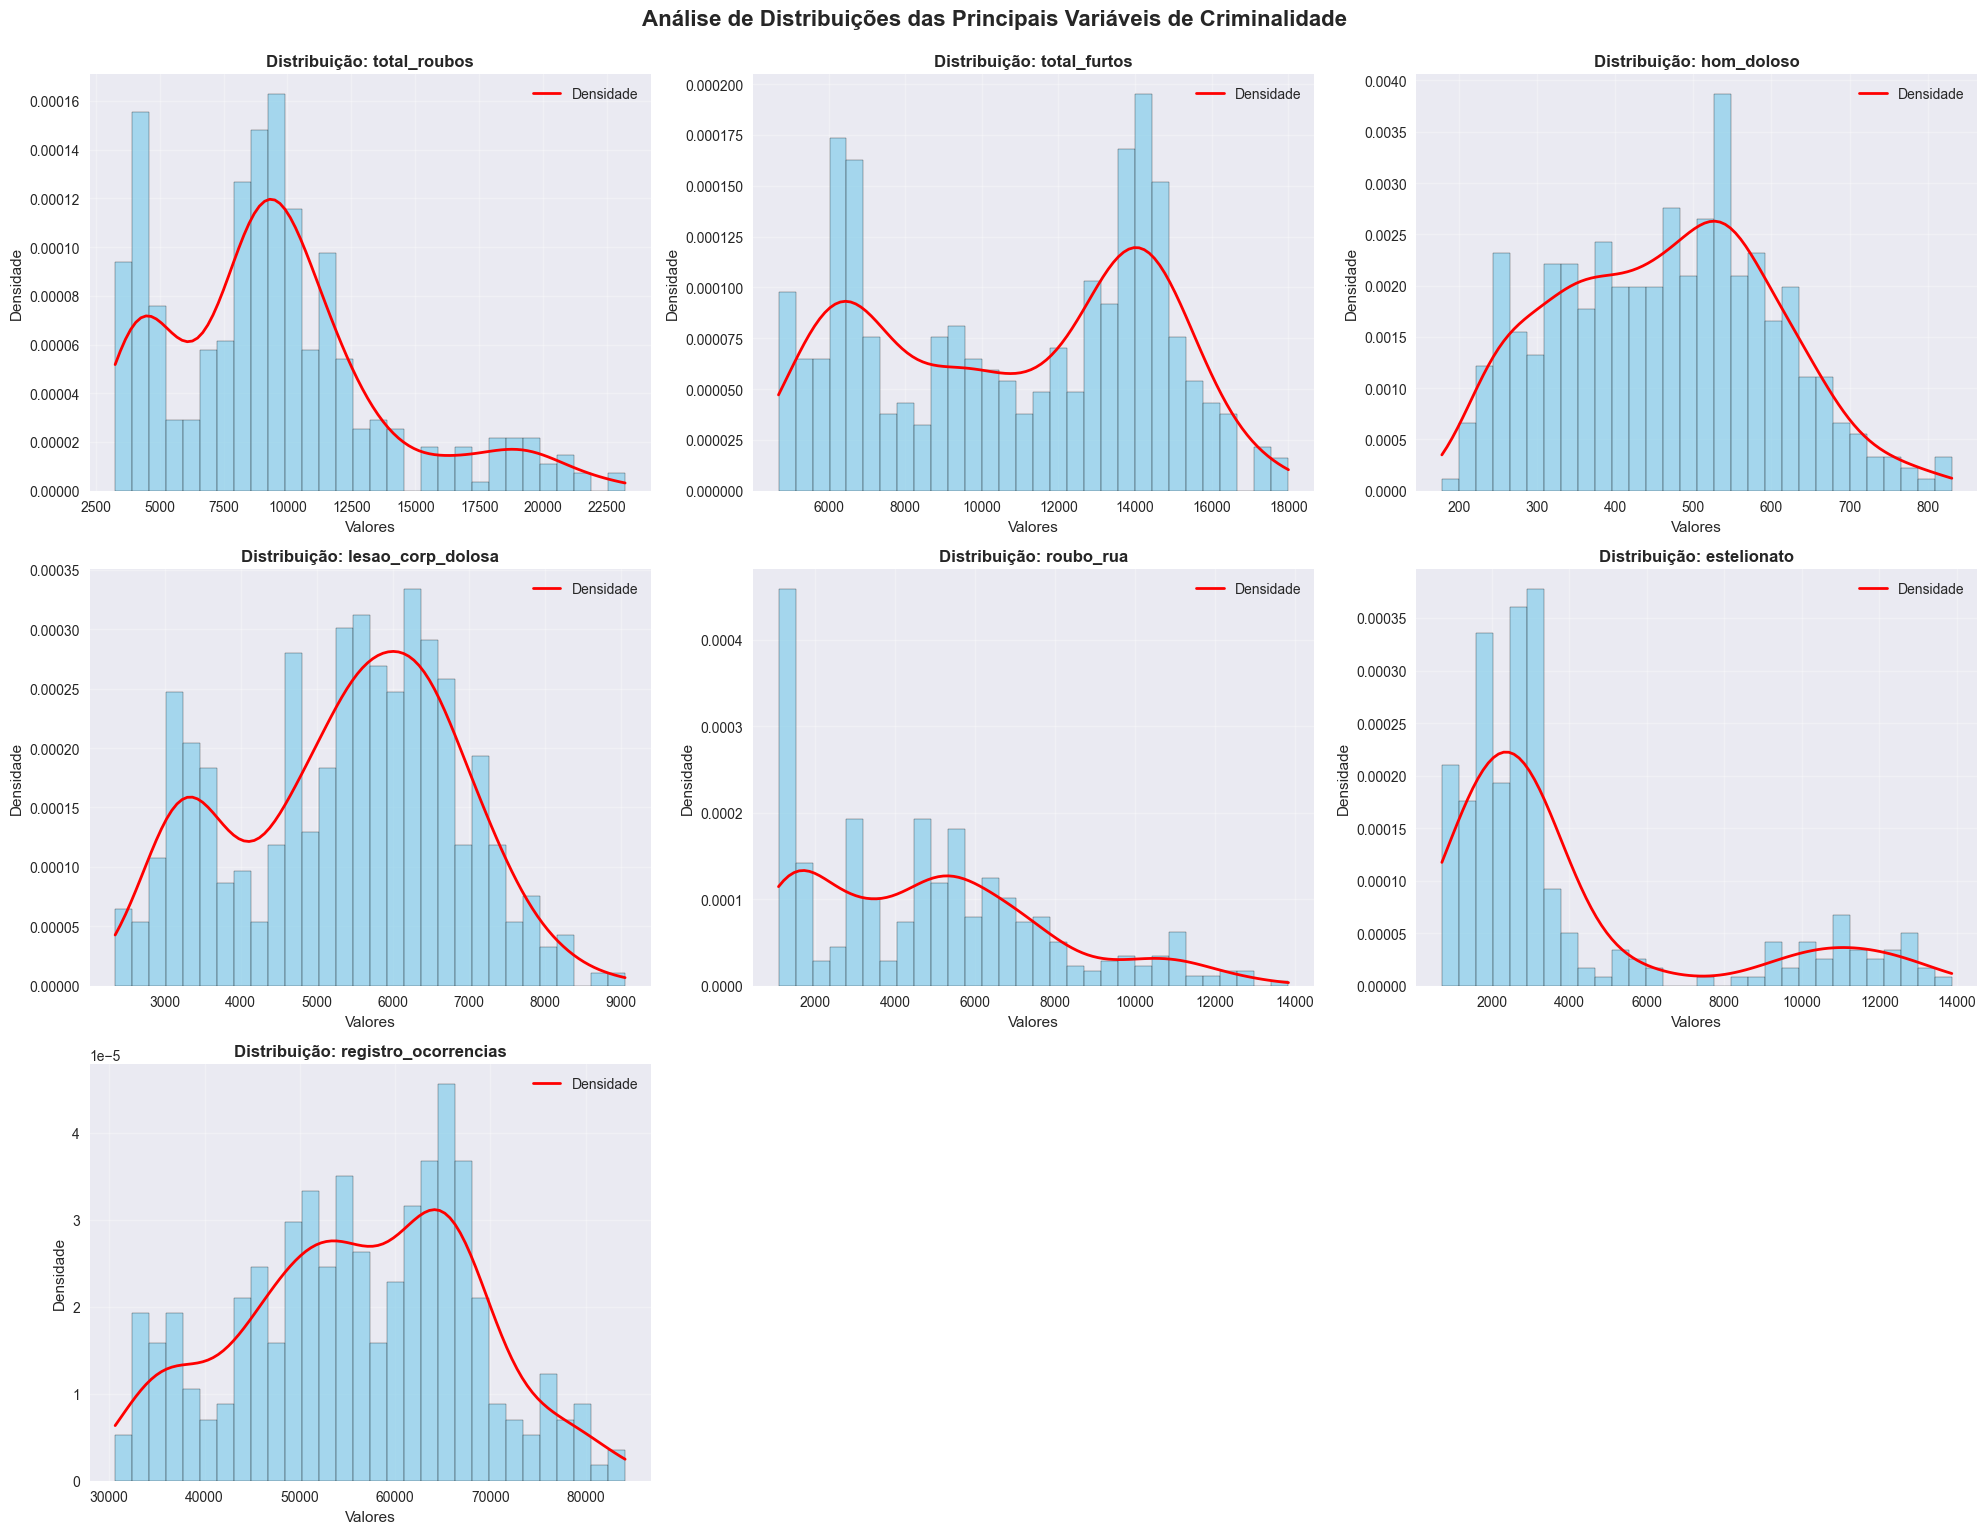

In [16]:
# Análise das distribuições das principais variáveis
print("📊 ANÁLISE DE DISTRIBUIÇÕES - PRINCIPAIS VARIÁVEIS")
print("="*70)

# Selecionar as principais variáveis para análise detalhada
main_vars = ['total_roubos', 'total_furtos', 'hom_doloso', 'lesao_corp_dolosa', 
             'roubo_rua', 'estelionato', 'registro_ocorrencias']

# Visualização das distribuições
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.ravel()

for i, var in enumerate(main_vars):
    if var in df.columns:
        # Histograma com curva de densidade
        axes[i].hist(df[var].dropna(), bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')
        
        # Adicionar curva de densidade
        data_clean = df[var].dropna()
        if len(data_clean) > 0:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(data_clean)
            x_range = np.linspace(data_clean.min(), data_clean.max(), 100)
            axes[i].plot(x_range, kde(x_range), 'red', linewidth=2, label='Densidade')
        
        axes[i].set_title(f'Distribuição: {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Valores')
        axes[i].set_ylabel('Densidade')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

# Remover subplot extra
if len(main_vars) < 9:
    for j in range(len(main_vars), 9):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Análise de Distribuições das Principais Variáveis de Criminalidade', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [17]:
# Testes de normalidade para as principais variáveis
print("🧪 TESTES DE NORMALIDADE")
print("="*70)

normality_results = []

for var in main_vars:
    if var in df.columns:
        data = df[var].dropna()
        
        # Shapiro-Wilk test (recomendado para n < 5000)
        if len(data) < 5000:
            shapiro_stat, shapiro_p = shapiro(data)
        else:
            shapiro_stat, shapiro_p = np.nan, np.nan
        
        # Jarque-Bera test (bom para amostras grandes)
        jb_stat, jb_p = jarque_bera(data)
        
        # Anderson-Darling test
        ad_result = anderson(data, dist='norm')
        
        normality_results.append({
            'Variavel': var,
            'Shapiro_Stat': shapiro_stat,
            'Shapiro_p': shapiro_p,
            'JB_Stat': jb_stat,
            'JB_p': jb_p,
            'AD_Stat': ad_result.statistic,
            'Normal_Shapiro': 'Sim' if shapiro_p > 0.05 else 'Não' if not np.isnan(shapiro_p) else 'N/A',
            'Normal_JB': 'Sim' if jb_p > 0.05 else 'Não',
            'Assimetria': data.skew(),
            'Curtose': data.kurtosis()
        })

normality_df = pd.DataFrame(normality_results)
print("Resultados dos Testes de Normalidade:")
display(normality_df)

# Interpretação dos resultados
print(f"\n📋 INTERPRETAÇÃO DOS RESULTADOS:")
print("="*50)
normal_vars = normality_df[normality_df['Normal_JB'] == 'Sim']['Variavel'].tolist()
non_normal_vars = normality_df[normality_df['Normal_JB'] == 'Não']['Variavel'].tolist()

print(f"✅ Variáveis com distribuição normal (JB test): {len(normal_vars)}")
if normal_vars:
    print(f"   • {', '.join(normal_vars)}")

print(f"❌ Variáveis com distribuição não-normal (JB test): {len(non_normal_vars)}")
if non_normal_vars:
    print(f"   • {', '.join(non_normal_vars)}")

print(f"\n💡 Implicações para Machine Learning:")
print(f"   • {len(non_normal_vars)}/{len(main_vars)} variáveis não seguem distribuição normal")
print(f"   • Recomenda-se transformações para SVMs e Redes Neurais")
print(f"   • Árvores de Decisão são robustas à não-normalidade")

🧪 TESTES DE NORMALIDADE
Resultados dos Testes de Normalidade:


,Variavel,Shapiro_Stat,Shapiro_p,JB_Stat,JB_p,AD_Stat,Normal_Shapiro,Normal_JB,Assimetria,Curtose
0,total_roubos,0.925842,1.745799e-13,61.858296,3.695231e-14,7.924560,Não,Não,0.880528,0.722890
1,total_furtos,0.924856,1.381968e-13,34.010371,4.118525e-08,11.842600,Não,Não,-0.132843,-1.377635
2,hom_doloso,0.984028,1.507977e-04,8.182688,1.671675e-02,1.593181,Não,Não,0.102351,-0.649499
3,lesao_corp_dolosa,0.970950,2.328732e-07,13.171596,1.379826e-03,4.226822,Não,Não,-0.220203,-0.747789
4,roubo_rua,0.930479,5.396554e-13,30.443820,2.450240e-07,7.139821,Não,Não,0.655054,-0.217038
5,estelionato,0.726787,7.571927e-21,125.288793,6.221346e-28,31.334779,Não,Não,1.581423,1.120191
6,registro_ocorrencias,0.981605,4.028406e-04,6.511873,3.854470e-02,1.585563,Não,Não,-0.138832,-0.633041



📋 INTERPRETAÇÃO DOS RESULTADOS:
✅ Variáveis com distribuição normal (JB test): 0
❌ Variáveis com distribuição não-normal (JB test): 7
   • total_roubos, total_furtos, hom_doloso, lesao_corp_dolosa, roubo_rua, estelionato, registro_ocorrencias

💡 Implicações para Machine Learning:
   • 7/7 variáveis não seguem distribuição normal
   • Recomenda-se transformações para SVMs e Redes Neurais
   • Árvores de Decisão são robustas à não-normalidade


## 5. Análise de Correlações e Relações entre Variáveis

🔗 ANÁLISE DE CORRELAÇÕES


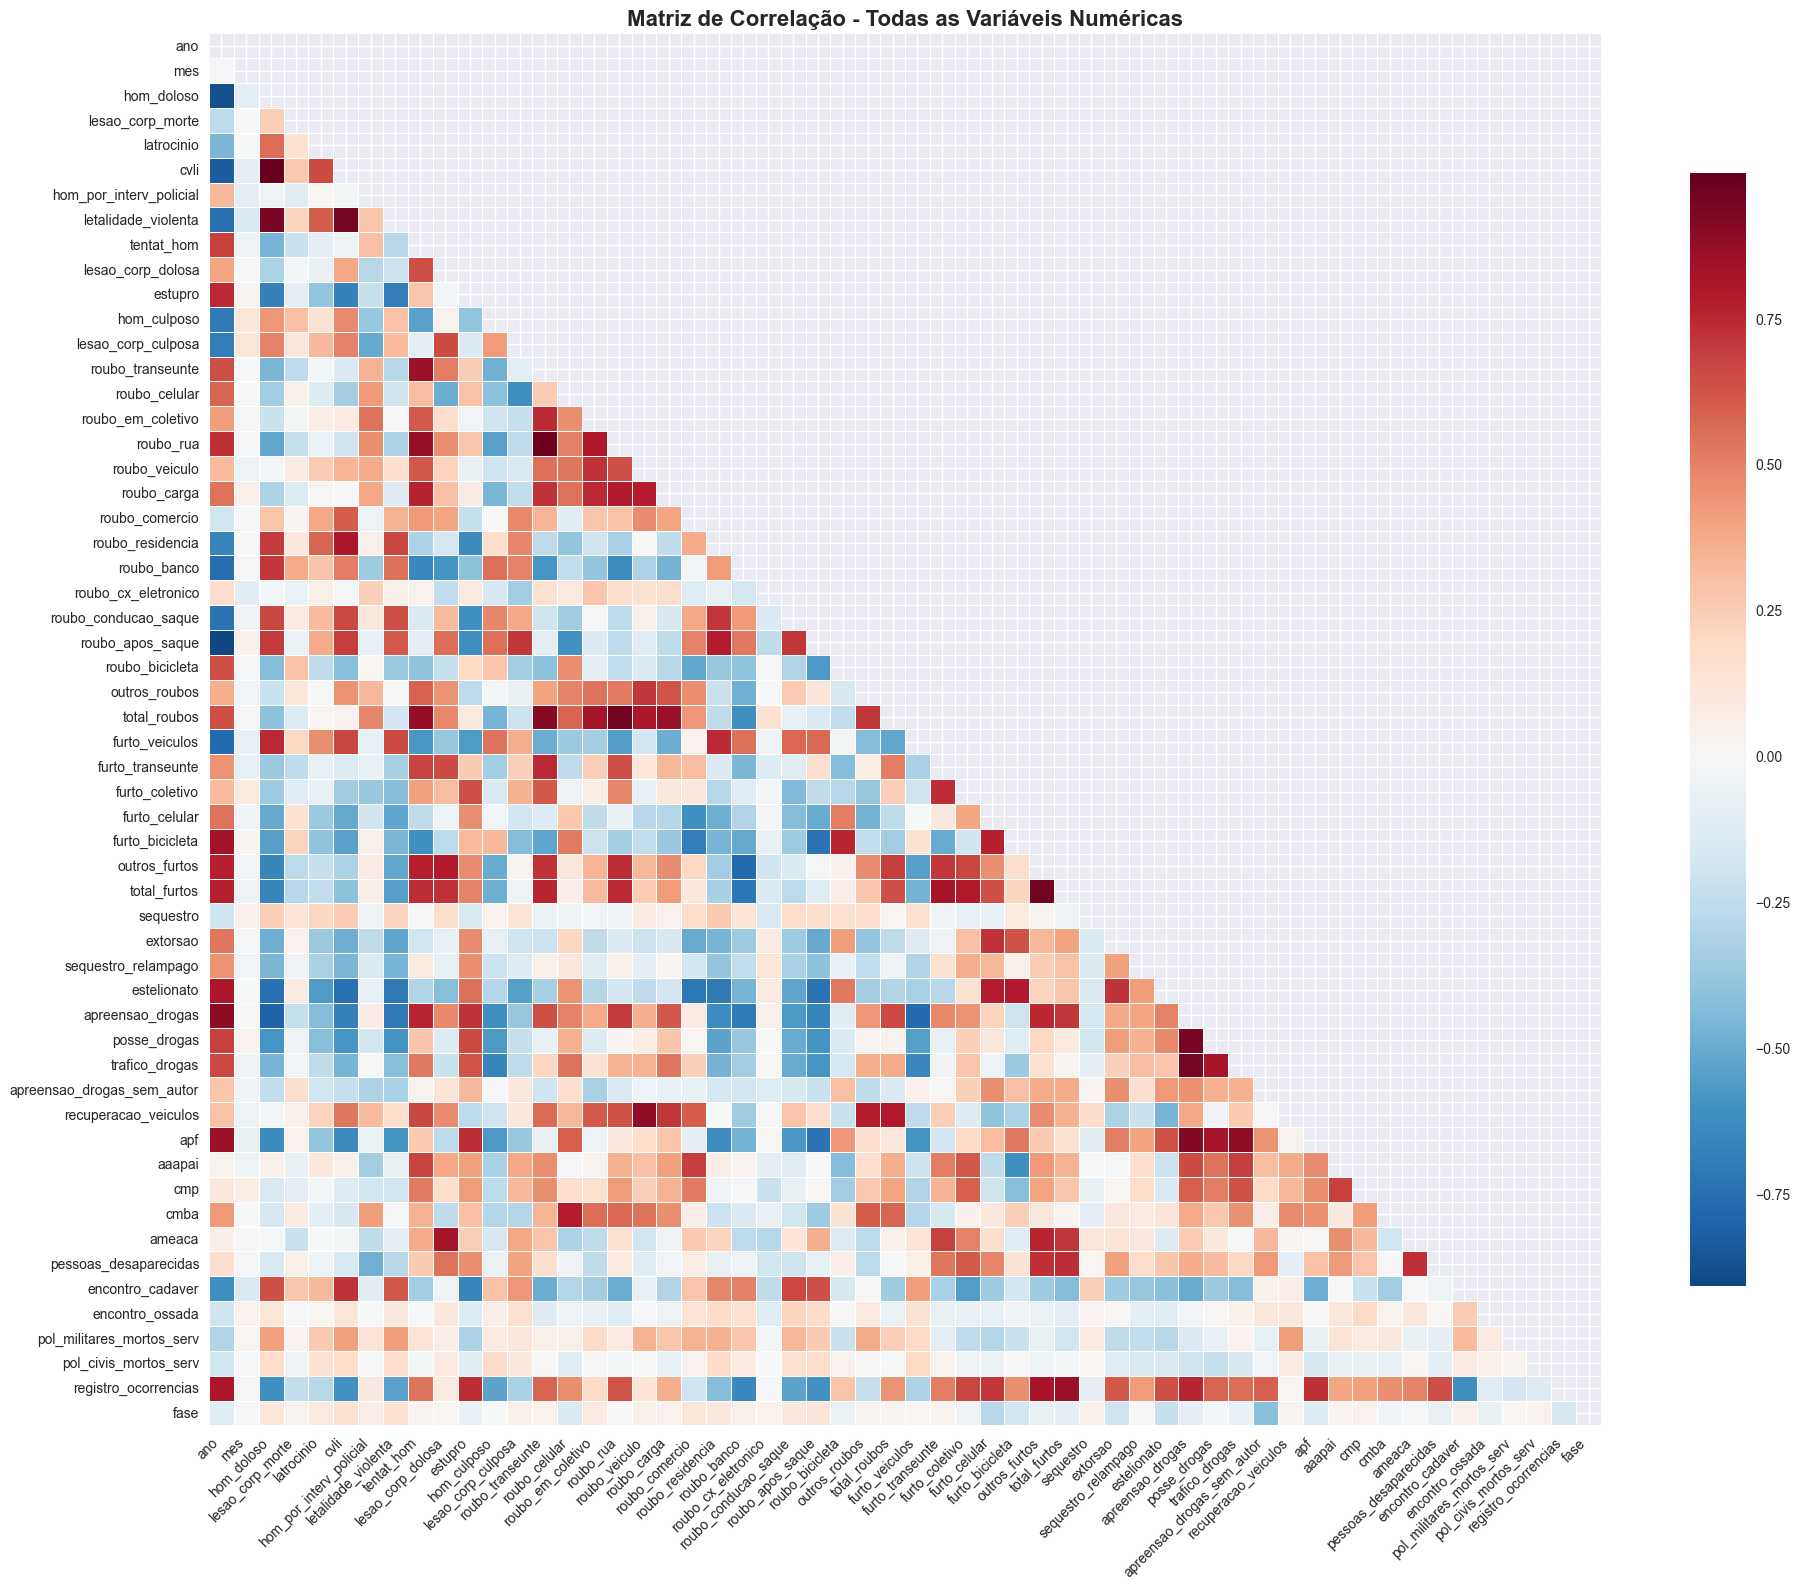


🔍 CORRELAÇÕES MAIS SIGNIFICATIVAS:
Encontradas 109 correlações altas (|r| >= 0.7):


,Var1,Var2,Correlacao,Abs_Correlacao
16,hom_doloso,cvli,0.998876,0.998876
43,roubo_transeunte,roubo_rua,0.974009,0.974009
55,roubo_rua,total_roubos,0.957198,0.957198
90,outros_furtos,total_furtos,0.956991,0.956991
101,apreensao_drogas,trafico_drogas,0.952540,0.952540
22,cvli,letalidade_violenta,0.951872,0.951872
17,hom_doloso,letalidade_violenta,0.942726,0.942726
100,apreensao_drogas,posse_drogas,0.942179,0.942179
102,apreensao_drogas,apf,0.909851,0.909851
7,ano,roubo_apos_saque,-0.908087,0.908087



📊 CORRELAÇÕES MODERADAS (0.5 <= |r| < 0.7): 210


,Var1,Var2,Correlacao,Abs_Correlacao
5,ano,hom_culposo,-0.699999,0.699999
38,hom_doloso,roubo_apos_saque,0.695601,0.695601
35,hom_doloso,roubo_residencia,0.694477,0.694477
183,roubo_rua,apreensao_drogas,0.694015,0.694015
310,trafico_drogas,aaapai,0.692843,0.692843
249,total_roubos,outros_furtos,0.690273,0.690273
60,cvli,roubo_apos_saque,0.688302,0.688302
203,roubo_comercio,aaapai,0.687642,0.687642
73,letalidade_violenta,estupro,-0.687203,0.687203
199,roubo_comercio,furto_bicicleta,-0.686481,0.686481


In [18]:
# Matriz de correlação completa
print("🔗 ANÁLISE DE CORRELAÇÕES")
print("="*70)

# Calcular matriz de correlação para variáveis numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Visualização da matriz de correlação
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Matriz de Correlação - Todas as Variáveis Numéricas', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identificar correlações mais fortes
print(f"\n🔍 CORRELAÇÕES MAIS SIGNIFICATIVAS:")
print("="*50)

# Função para encontrar correlações altas
def find_high_correlations(corr_matrix, threshold=0.7):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) >= threshold:
                high_corr_pairs.append({
                    'Var1': corr_matrix.columns[i],
                    'Var2': corr_matrix.columns[j],
                    'Correlacao': corr_val,
                    'Abs_Correlacao': abs(corr_val)
                })
    return pd.DataFrame(high_corr_pairs).sort_values('Abs_Correlacao', ascending=False)

high_corr_df = find_high_correlations(correlation_matrix, threshold=0.7)

if len(high_corr_df) > 0:
    print(f"Encontradas {len(high_corr_df)} correlações altas (|r| >= 0.7):")
    display(high_corr_df.head(20))
else:
    print("Nenhuma correlação alta encontrada (|r| >= 0.7)")
    
# Correlações moderadas
moderate_corr_df = find_high_correlations(correlation_matrix, threshold=0.5)
moderate_corr_df = moderate_corr_df[moderate_corr_df['Abs_Correlacao'] < 0.7]

print(f"\n📊 CORRELAÇÕES MODERADAS (0.5 <= |r| < 0.7): {len(moderate_corr_df)}")
if len(moderate_corr_df) > 0:
    display(moderate_corr_df.head(10))

In [19]:
# Análise específica para Machine Learning
print(f"\n🤖 IMPLICAÇÕES PARA MACHINE LEARNING:")
print("="*70)

# Identificar problemas de multicolinearidade
highly_correlated_groups = []
very_high_corr = high_corr_df[high_corr_df['Abs_Correlacao'] > 0.95]

print(f"⚠️  PROBLEMAS DE MULTICOLINEARIDADE (|r| > 0.95):")
print(f"   • {len(very_high_corr)} pares de variáveis altamente correlacionadas")
print(f"   • Isso pode prejudicar SVMs e Redes Neurais")
print(f"   • Árvores de Decisão são mais robustas à multicolinearidade")

if len(very_high_corr) > 0:
    print(f"\n   📋 Principais pares problemáticos:")
    for idx, row in very_high_corr.head(5).iterrows():
        print(f"      • {row['Var1']} ↔ {row['Var2']}: r = {row['Correlacao']:.3f}")

# Análise de variáveis redundantes
print(f"\n🔄 VARIÁVEIS POTENCIALMENTE REDUNDANTES:")
redundant_vars = set()
for idx, row in very_high_corr.iterrows():
    if row['Var2'] not in ['total_roubos', 'total_furtos', 'cvli', 'letalidade_violenta']:
        redundant_vars.add(row['Var2'])

print(f"   • {len(redundant_vars)} variáveis podem ser removidas para reduzir redundância")
if redundant_vars:
    redundant_list = list(redundant_vars)[:10]  # Mostrar apenas 10
    print(f"   • Exemplos: {', '.join(redundant_list)}")

# Correlações com variáveis temporais
temporal_corrs = []
for col in numeric_cols:
    if col not in ['ano', 'mes']:
        corr_ano = correlation_matrix.loc['ano', col]
        if abs(corr_ano) > 0.3:
            temporal_corrs.append({'Variavel': col, 'Corr_Ano': corr_ano})

temporal_df = pd.DataFrame(temporal_corrs).sort_values('Corr_Ano', key=abs, ascending=False)

print(f"\n📈 TENDÊNCIAS TEMPORAIS SIGNIFICATIVAS (|r| > 0.3 com ano):")
print(f"   • {len(temporal_df)} variáveis mostram tendência temporal")
if len(temporal_df) > 0:
    print(f"   • Top 5 crescentes:")
    growing_crimes = temporal_df[temporal_df['Corr_Ano'] > 0].head(5)
    for _, row in growing_crimes.iterrows():
        print(f"     ↗️ {row['Variavel']}: r = {row['Corr_Ano']:.3f}")
        
    print(f"   • Top 5 decrescentes:")
    declining_crimes = temporal_df[temporal_df['Corr_Ano'] < 0].head(5)
    for _, row in declining_crimes.iterrows():
        print(f"     ↘️ {row['Variavel']}: r = {row['Corr_Ano']:.3f}")


🤖 IMPLICAÇÕES PARA MACHINE LEARNING:
⚠️  PROBLEMAS DE MULTICOLINEARIDADE (|r| > 0.95):
   • 6 pares de variáveis altamente correlacionadas
   • Isso pode prejudicar SVMs e Redes Neurais
   • Árvores de Decisão são mais robustas à multicolinearidade

   📋 Principais pares problemáticos:
      • hom_doloso ↔ cvli: r = 0.999
      • roubo_transeunte ↔ roubo_rua: r = 0.974
      • roubo_rua ↔ total_roubos: r = 0.957
      • outros_furtos ↔ total_furtos: r = 0.957
      • apreensao_drogas ↔ trafico_drogas: r = 0.953

🔄 VARIÁVEIS POTENCIALMENTE REDUNDANTES:
   • 2 variáveis podem ser removidas para reduzir redundância
   • Exemplos: roubo_rua, trafico_drogas

📈 TENDÊNCIAS TEMPORAIS SIGNIFICATIVAS (|r| > 0.3 com ano):
   • 41 variáveis mostram tendência temporal
   • Top 5 crescentes:
     ↗️ apreensao_drogas: r = 0.889
     ↗️ apf: r = 0.854
     ↗️ furto_bicicleta: r = 0.839
     ↗️ estelionato: r = 0.810
     ↗️ registro_ocorrencias: r = 0.809
   • Top 5 decrescentes:
     ↘️ roubo_apos_s

## 6. Detecção e Análise de Outliers

🎯 ANÁLISE DE OUTLIERS
Análise de Outliers por Variável:


,Variavel,N_Total,Outliers_IQR,Pct_IQR,Outliers_ZScore,Pct_ZScore,Min,Max,Q1,Q3
0,total_roubos,416,24,5.769231,2,0.480769,3261.0,23203.0,6518.00,11297.00
1,total_furtos,416,0,0.000000,0,0.000000,4691.0,18003.0,6912.00,14058.50
2,hom_doloso,416,0,0.000000,0,0.000000,178.0,831.0,350.00,557.25
3,lesao_corp_dolosa,416,0,0.000000,0,0.000000,2350.0,9050.0,4401.00,6443.75
4,roubo_rua,416,1,0.240385,1,0.240385,1086.0,13833.0,1906.75,6603.75
5,estelionato,272,47,17.279412,0,0.000000,717.0,13870.0,1859.50,3582.75
6,registro_ocorrencias,320,0,0.000000,0,0.000000,30621.0,84129.0,47675.00,65278.25


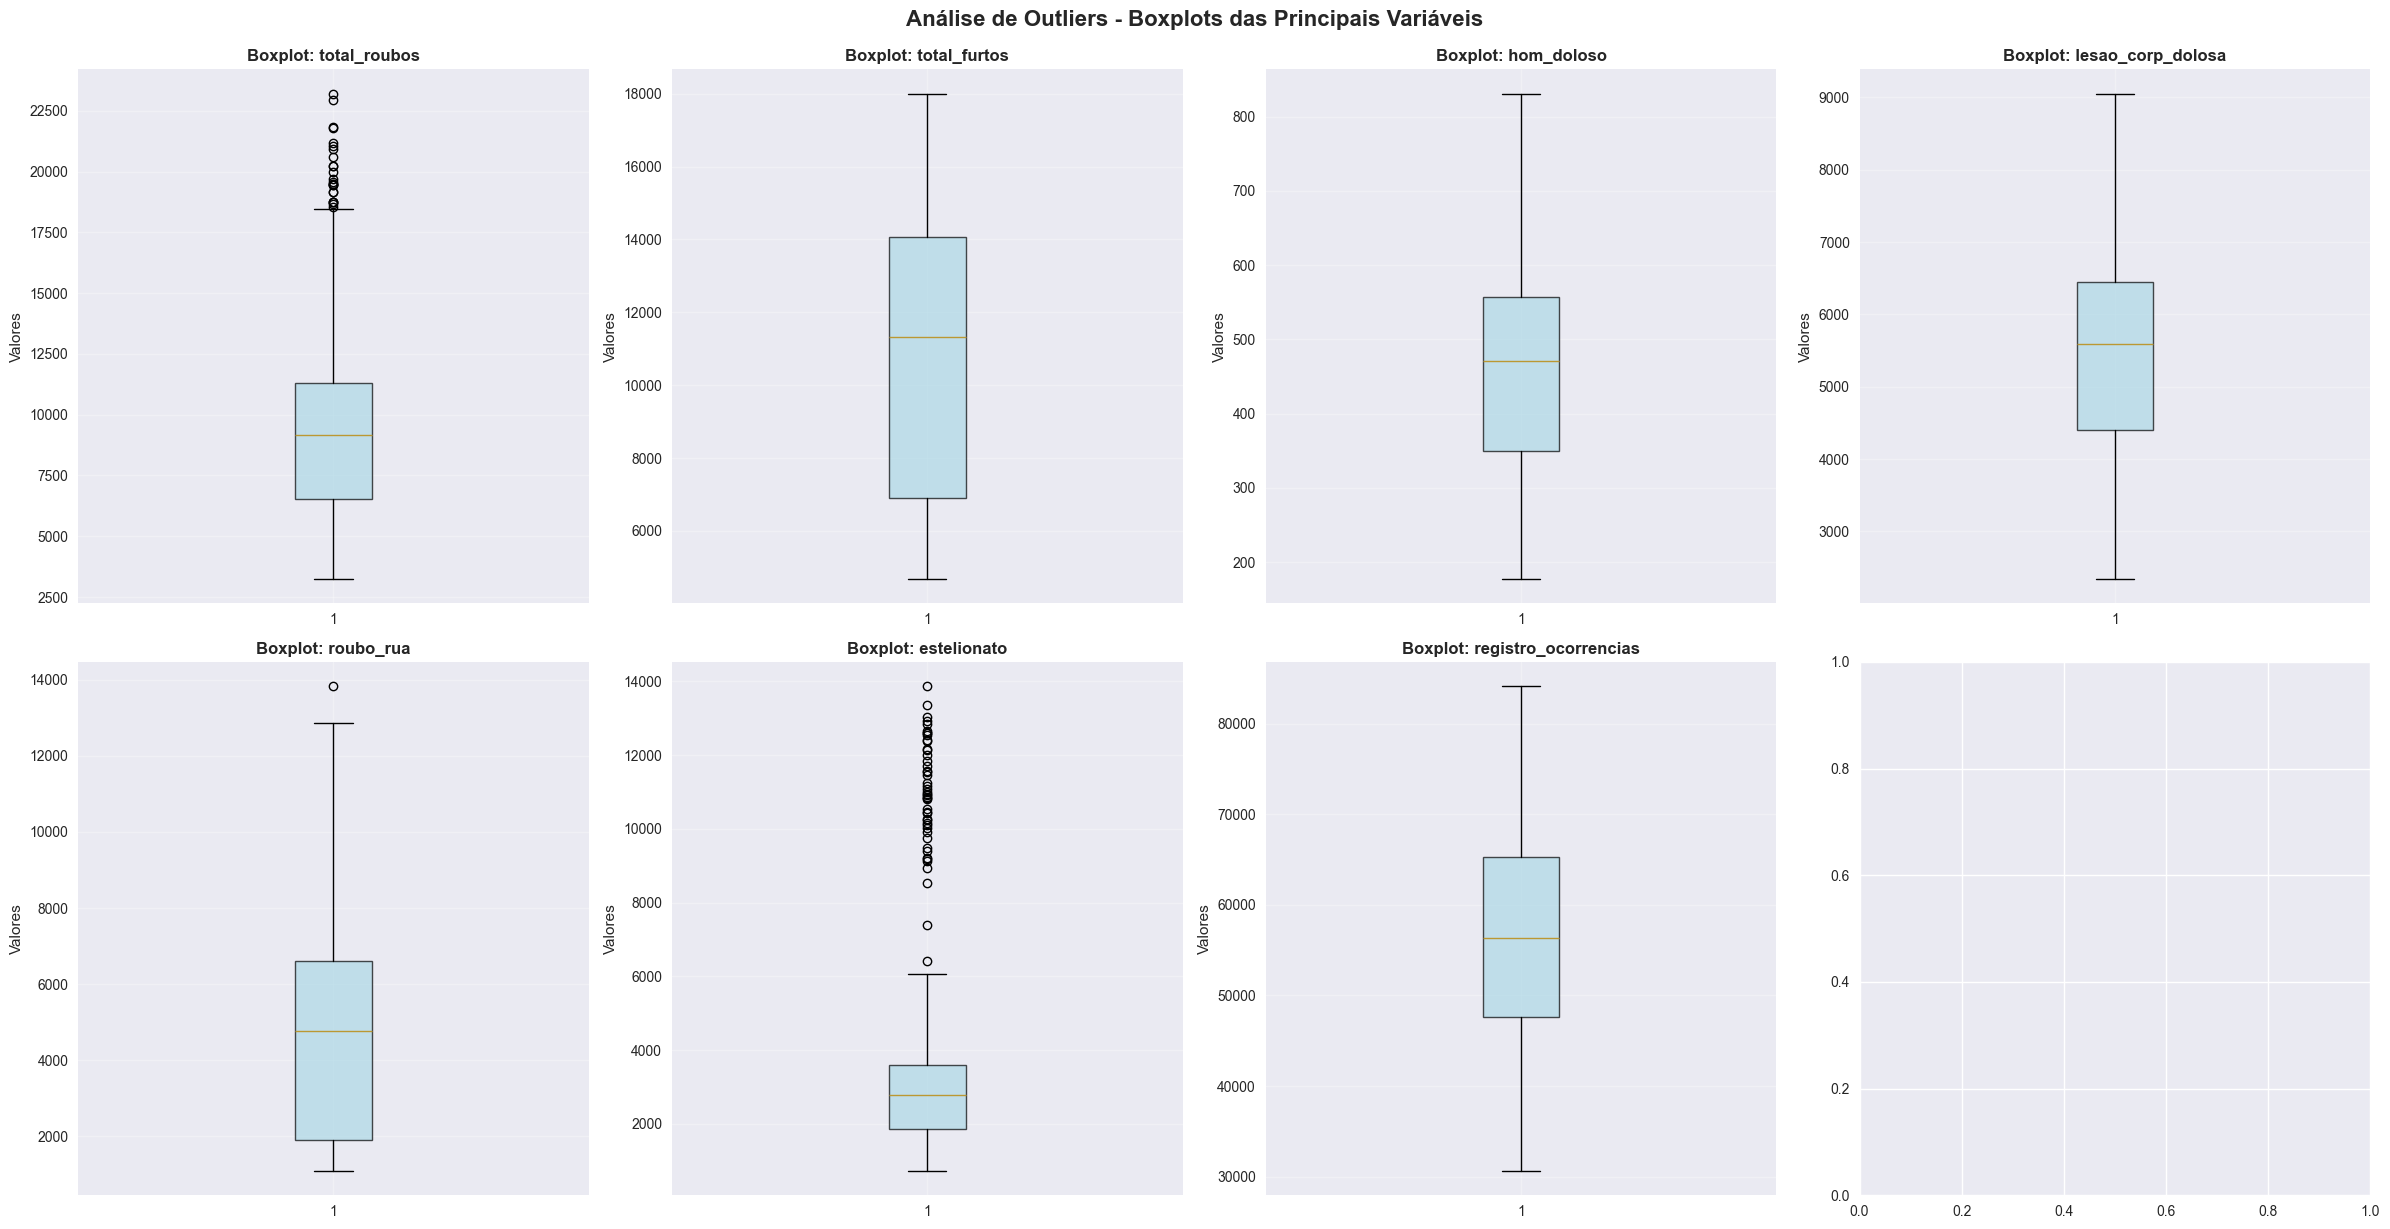

In [20]:
# Análise de outliers usando diferentes métodos
print("🎯 ANÁLISE DE OUTLIERS")
print("="*70)

def detect_outliers_iqr(data):
    """Detecta outliers usando o método IQR"""
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

def detect_outliers_zscore(data, threshold=3):
    """Detecta outliers usando Z-score"""
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

# Analisar outliers nas principais variáveis
outlier_analysis = []

for var in main_vars:
    if var in df.columns:
        data = df[var].dropna()
        
        # Método IQR
        outliers_iqr = detect_outliers_iqr(data)
        n_outliers_iqr = outliers_iqr.sum()
        pct_outliers_iqr = (n_outliers_iqr / len(data)) * 100
        
        # Método Z-score
        outliers_zscore = detect_outliers_zscore(data)
        n_outliers_zscore = outliers_zscore.sum()
        pct_outliers_zscore = (n_outliers_zscore / len(data)) * 100
        
        outlier_analysis.append({
            'Variavel': var,
            'N_Total': len(data),
            'Outliers_IQR': n_outliers_iqr,
            'Pct_IQR': pct_outliers_iqr,
            'Outliers_ZScore': n_outliers_zscore,
            'Pct_ZScore': pct_outliers_zscore,
            'Min': data.min(),
            'Max': data.max(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75)
        })

outlier_df = pd.DataFrame(outlier_analysis)
print("Análise de Outliers por Variável:")
display(outlier_df)

# Visualização de boxplots para identificar outliers
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.ravel()

for i, var in enumerate(main_vars):
    if var in df.columns and i < 8:
        bp = axes[i].boxplot(df[var].dropna(), patch_artist=True)
        axes[i].set_title(f'Boxplot: {var}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Valores')
        axes[i].grid(True, alpha=0.3)
        
        # Colorir o boxplot
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][0].set_alpha(0.7)

plt.tight_layout()
plt.suptitle('Análise de Outliers - Boxplots das Principais Variáveis', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

## 7. Análise Temporal e Tendências

📈 ANÁLISE TEMPORAL E TENDÊNCIAS


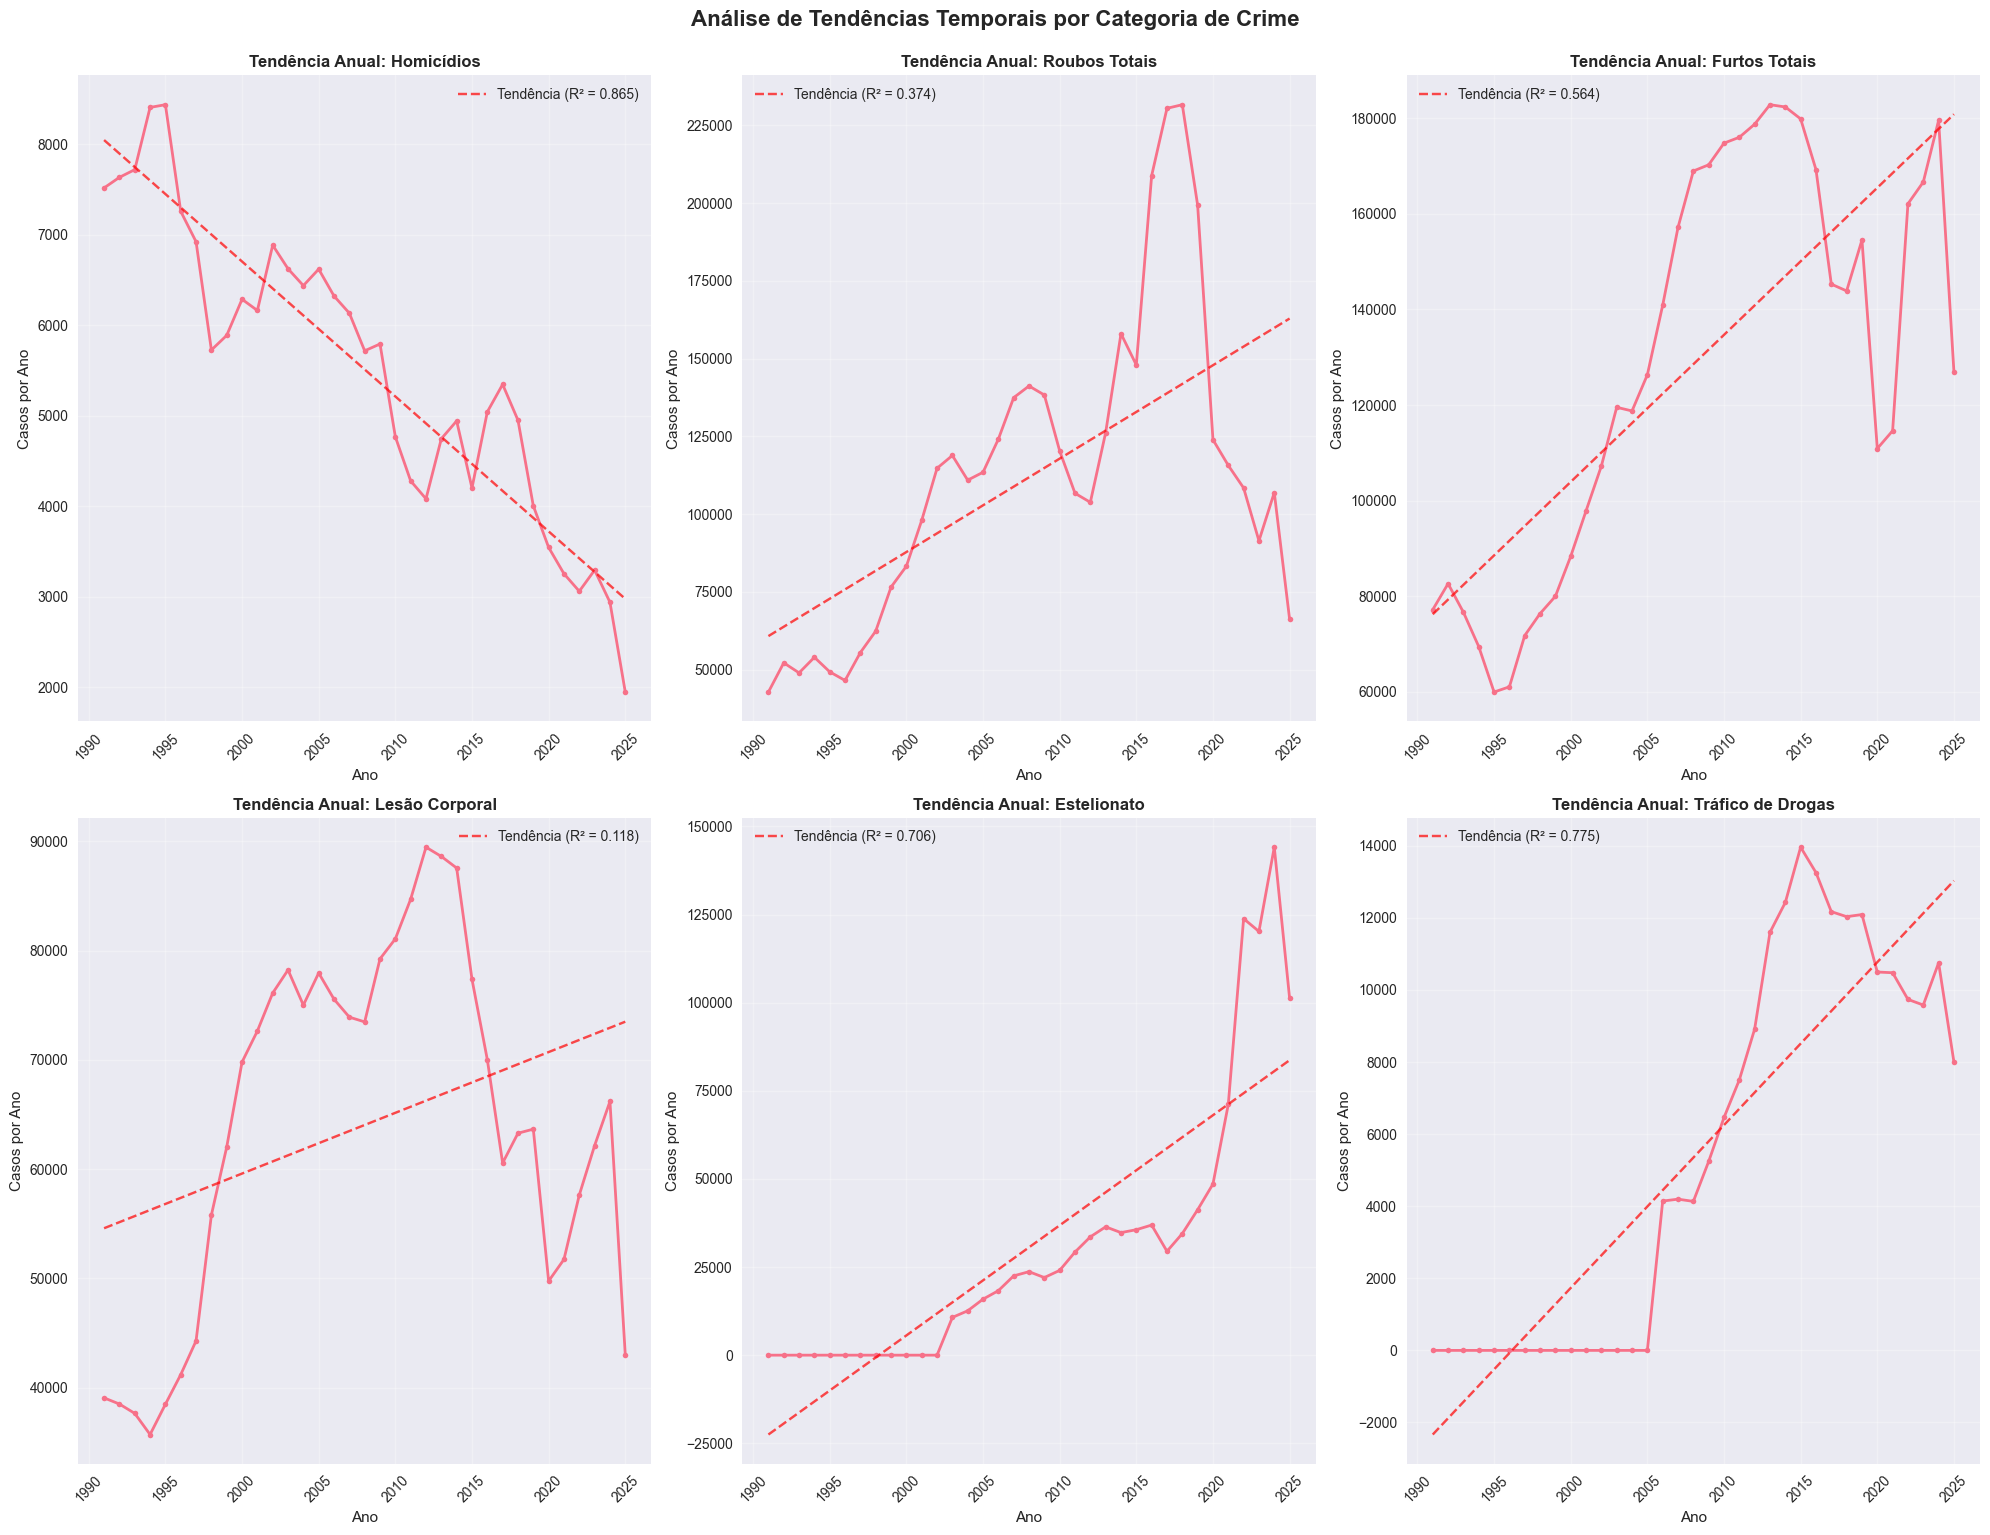


📊 ANÁLISE ESTATÍSTICA DAS TENDÊNCIAS:


,Crime_Type,Variable,Slope,R_Squared,P_Value,Pct_Change_Total,Trend,Significance
0,Homicídios,hom_doloso,-149.180112,0.865059,6.550966e-16,-64.254798,Decrescente,Significativa
1,Roubos Totais,total_roubos,3002.547899,0.373887,9.526918e-05,83.808763,Crescente,Significativa
2,Furtos Totais,total_furtos,3075.454902,0.563614,2.054062e-07,100.020717,Crescente,Significativa
3,Lesão Corporal,lesao_corp_dolosa,556.116527,0.118328,4.303431e-02,48.768396,Crescente,Significativa
4,Estelionato,estelionato,3123.942857,0.705517,2.815809e-10,inf,Crescente,Significativa
5,Tráfico de Drogas,trafico_drogas,451.928852,0.774951,3.190122e-12,inf,Crescente,Significativa


In [21]:
# Análise de séries temporais
print("📈 ANÁLISE TEMPORAL E TENDÊNCIAS")
print("="*70)

# Criar uma nova coluna de data para análises temporais
df['data'] = pd.to_datetime(df['ano'].astype(str) + '-' + df['mes'].astype(str).str.zfill(2) + '-01')

# Análise de tendências anuais
plt.figure(figsize=(20, 15))

# Selecionar variáveis representativas de cada categoria
crime_categories_vars = {
    'Homicídios': 'hom_doloso',
    'Roubos Totais': 'total_roubos',
    'Furtos Totais': 'total_furtos',
    'Lesão Corporal': 'lesao_corp_dolosa',
    'Estelionato': 'estelionato',
    'Tráfico de Drogas': 'trafico_drogas'
}

# Plotar 6 gráficos das principais categorias
for i, (category, var) in enumerate(crime_categories_vars.items(), 1):
    plt.subplot(2, 3, i)
    
    if var in df.columns:
        # Agrupar por ano para mostrar tendência
        yearly_data = df.groupby('ano')[var].sum().reset_index()
        
        plt.plot(yearly_data['ano'], yearly_data[var], marker='o', linewidth=2, markersize=4)
        plt.title(f'Tendência Anual: {category}', fontsize=12, fontweight='bold')
        plt.xlabel('Ano')
        plt.ylabel('Casos por Ano')
        plt.grid(True, alpha=0.3)
        
        # Adicionar linha de tendência
        from scipy import stats
        slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_data['ano'], yearly_data[var])
        line = slope * yearly_data['ano'] + intercept
        plt.plot(yearly_data['ano'], line, 'r--', alpha=0.7, 
                label=f'Tendência (R² = {r_value**2:.3f})')
        plt.legend()
        
        # Rotacionar labels do eixo x
        plt.xticks(rotation=45)

plt.tight_layout()
plt.suptitle('Análise de Tendências Temporais por Categoria de Crime', 
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Análise estatística das tendências
print(f"\n📊 ANÁLISE ESTATÍSTICA DAS TENDÊNCIAS:")
print("="*50)

trend_analysis = []
for category, var in crime_categories_vars.items():
    if var in df.columns:
        yearly_data = df.groupby('ano')[var].sum()
        slope, intercept, r_value, p_value, std_err = stats.linregress(yearly_data.index, yearly_data.values)
        
        # Calcular mudança percentual
        first_year_avg = yearly_data.iloc[:3].mean()  # Média dos 3 primeiros anos
        last_year_avg = yearly_data.iloc[-3:].mean()   # Média dos 3 últimos anos
        pct_change = ((last_year_avg - first_year_avg) / first_year_avg) * 100
        
        trend_analysis.append({
            'Crime_Type': category,
            'Variable': var,
            'Slope': slope,
            'R_Squared': r_value**2,
            'P_Value': p_value,
            'Pct_Change_Total': pct_change,
            'Trend': 'Crescente' if slope > 0 else 'Decrescente',
            'Significance': 'Significativa' if p_value < 0.05 else 'Não Significativa'
        })

trend_df = pd.DataFrame(trend_analysis)
display(trend_df)

## 8. Preparação dos Dados para Machine Learning

In [22]:
# Análise da qualidade dos dados para ML
print("🤖 PREPARAÇÃO PARA MACHINE LEARNING")
print("="*70)

# 1. Análise de correlação com informação mútua
print("🔍 SELEÇÃO DE FEATURES BASEADA EM INFORMAÇÃO MÚTUA")
print("="*60)

# Preparar dados para análise de feature importance
# Remover colunas não numéricas e com muitos valores ausentes
ml_data = df.select_dtypes(include=[np.number]).copy()
ml_data = ml_data.dropna(axis=1, thresh=len(ml_data)*0.7)  # Manter colunas com pelo menos 70% dos dados

print(f"Dados para ML: {ml_data.shape[0]} registros, {ml_data.shape[1]} features")

# Selecionar diferentes targets potenciais para análise
potential_targets = ['total_roubos', 'total_furtos', 'hom_doloso', 'lesao_corp_dolosa', 'registro_ocorrencias']
features_to_exclude = ['ano', 'mes'] + potential_targets

# Análise de importância para cada target
feature_importance_results = {}

for target in potential_targets:
    if target in ml_data.columns:
        print(f"\n🎯 Análise para target: {target}")
        
        # Preparar features (excluir target e variáveis temporais)
        feature_cols = [col for col in ml_data.columns if col not in features_to_exclude]
        
        # Remover registros com valores ausentes para esta análise
        target_data = ml_data[feature_cols + [target]].dropna()
        
        if len(target_data) > 50:  # Garantir dados suficientes
            X = target_data[feature_cols]
            y = target_data[target]
            
            # Calcular informação mútua
            mi_scores = mutual_info_regression(X, y, random_state=42)
            mi_df = pd.DataFrame({
                'Feature': feature_cols,
                'MI_Score': mi_scores
            }).sort_values('MI_Score', ascending=False)
            
            feature_importance_results[target] = mi_df
            
            print(f"   📊 Top 10 features mais importantes:")
            for idx, row in mi_df.head(10).iterrows():
                print(f"      {row['Feature']:<25}: {row['MI_Score']:.4f}")

# Análise de balanceamento dos targets
print(f"\n⚖️ ANÁLISE DE DISTRIBUIÇÃO DOS TARGETS")
print("="*60)

target_analysis = []
for target in potential_targets:
    if target in ml_data.columns:
        data = ml_data[target].dropna()
        
        target_analysis.append({
            'Target': target,
            'N_Samples': len(data),
            'Mean': data.mean(),
            'Std': data.std(),
            'Min': data.min(),
            'Max': data.max(),
            'CV': data.std() / data.mean() if data.mean() != 0 else 0,
            'Skewness': data.skew(),
            'Kurtosis': data.kurtosis()
        })

target_df = pd.DataFrame(target_analysis)
display(target_df)

🤖 PREPARAÇÃO PARA MACHINE LEARNING
🔍 SELEÇÃO DE FEATURES BASEADA EM INFORMAÇÃO MÚTUA
Dados para ML: 416 registros, 34 features

🎯 Análise para target: total_roubos
   📊 Top 10 features mais importantes:
      roubo_rua                : 1.3800
      roubo_transeunte         : 1.1121
      roubo_veiculo            : 0.7205
      roubo_celular            : 0.7058
      outros_roubos            : 0.6015
      roubo_em_coletivo        : 0.5970
      recuperacao_veiculos     : 0.5516
      tentat_hom               : 0.5454
      roubo_carga              : 0.5206
      lesao_corp_culposa       : 0.5095

🎯 Análise para target: total_furtos
   📊 Top 10 features mais importantes:
      outros_furtos            : 1.1595
      furto_transeunte         : 1.0004
      roubo_transeunte         : 0.5966
      roubo_rua                : 0.5555
      lesao_corp_culposa       : 0.5026
      ameaca                   : 0.5023
      encontro_cadaver         : 0.4853
      furto_veiculos           : 0.4123
 

,Target,N_Samples,Mean,Std,Min,Max,CV,Skewness,Kurtosis
0,total_roubos,416,9407.632212,4239.460953,3261.0,23203.0,0.450641,0.880528,0.722890
1,total_furtos,416,10814.310096,3650.127123,4691.0,18003.0,0.337528,-0.132843,-1.377635
2,hom_doloso,416,463.668269,137.761399,178.0,831.0,0.297112,0.102351,-0.649499
3,lesao_corp_dolosa,416,5387.713942,1430.189787,2350.0,9050.0,0.265454,-0.220203,-0.747789
4,registro_ocorrencias,320,56085.778125,12047.997305,30621.0,84129.0,0.214814,-0.138832,-0.633041


In [23]:
# Recomendações específicas para cada algoritmo de ML
print(f"\n🎯 RECOMENDAÇÕES POR ALGORITMO DE MACHINE LEARNING")
print("="*70)

print("🌳 ÁRVORES DE DECISÃO:")
print("   ✅ VANTAGENS com estes dados:")
print("   • Robustas à não-normalidade das variáveis")
print("   • Lidam bem com multicolinearidade")
print("   • Não precisam de normalização")
print("   • Interpretáveis (importante para análise criminal)")
print("   • Podem capturar relações não-lineares")
print("   ⚠️  CUIDADOS:")
print("   • Tendência ao overfitting com muitas features")
print("   • Usar validação cruzada e poda")

print(f"\n🧠 REDES NEURAIS:")
print("   ⚠️  DESAFIOS com estes dados:")
print("   • Distribuições não-normais (requer normalização)")
print("   • Multicolinearidade alta pode prejudicar treinamento")
print("   • Muitos valores ausentes em algumas variáveis")
print("   🔧 PREPROCESSAMENTO NECESSÁRIO:")
print("   • StandardScaler ou MinMaxScaler")
print("   • Remoção de features altamente correlacionadas")
print("   • Imputação cuidadosa de valores ausentes")
print("   • Regularização (dropout, L1/L2)")

print(f"\n⚡ SVM (Support Vector Machines):")
print("   ⚠️  DESAFIOS com estes dados:")
print("   • Muito sensível à escala das features")
print("   • Multicolinearidade pode prejudicar performance")
print("   • Computacionalmente caro com muitos dados")
print("   🔧 PREPROCESSAMENTO NECESSÁRIO:")
print("   • Normalização obrigatória (StandardScaler)")
print("   • Seleção de features importante")
print("   • Remoção de outliers pode melhorar performance")

print(f"\n💡 ESTRATÉGIAS DE PREPROCESSAMENTO RECOMENDADAS:")
print("="*60)

# Analisar correlações problemáticas
high_corr_features = []
for idx, row in very_high_corr.iterrows():
    if row['Abs_Correlacao'] > 0.98:
        high_corr_features.extend([row['Var1'], row['Var2']])

unique_problematic = list(set(high_corr_features))

print("🔄 REMOÇÃO DE MULTICOLINEARIDADE:")
print(f"   • Features altamente correlacionadas (r > 0.98): {len(unique_problematic)}")
print(f"   • Considerar remoção: {', '.join(unique_problematic[:5])}...")

print(f"\n📊 TRATAMENTO DE VALORES AUSENTES:")
missing_strategy = []
for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    if missing_pct > 0:
        if missing_pct < 5:
            strategy = "Imputação por média/mediana"
        elif missing_pct < 20:
            strategy = "Imputação avançada (KNN/Iterative)"
        else:
            strategy = "Considerar remoção da feature"
        missing_strategy.append(f"   • {col} ({missing_pct:.1f}%): {strategy}")

print(f"Estratégias por coluna (top 10):")
for strategy in missing_strategy[:10]:
    print(strategy)

print(f"\n🎯 SELEÇÃO DE VARIÁVEIS TARGET:")
print("   • total_roubos: Boa variabilidade, tendência crescente")
print("   • total_furtos: Distribuição mais normal, boa para regressão")
print("   • hom_doloso: Tendência decrescente forte, bom para análise temporal")
print("   • registro_ocorrencias: Maior variância, pode ser bom target agregado")


🎯 RECOMENDAÇÕES POR ALGORITMO DE MACHINE LEARNING
🌳 ÁRVORES DE DECISÃO:
   ✅ VANTAGENS com estes dados:
   • Robustas à não-normalidade das variáveis
   • Lidam bem com multicolinearidade
   • Não precisam de normalização
   • Interpretáveis (importante para análise criminal)
   • Podem capturar relações não-lineares
   ⚠️  CUIDADOS:
   • Tendência ao overfitting com muitas features
   • Usar validação cruzada e poda

🧠 REDES NEURAIS:
   ⚠️  DESAFIOS com estes dados:
   • Distribuições não-normais (requer normalização)
   • Multicolinearidade alta pode prejudicar treinamento
   • Muitos valores ausentes em algumas variáveis
   🔧 PREPROCESSAMENTO NECESSÁRIO:
   • StandardScaler ou MinMaxScaler
   • Remoção de features altamente correlacionadas
   • Imputação cuidadosa de valores ausentes
   • Regularização (dropout, L1/L2)

⚡ SVM (Support Vector Machines):
   ⚠️  DESAFIOS com estes dados:
   • Muito sensível à escala das features
   • Multicolinearidade pode prejudicar performance
   •

## 9. Conclusões e Avaliação da Qualidade dos Dados

In [24]:
# Avaliação final da qualidade dos dados para Machine Learning
print("🏆 AVALIAÇÃO FINAL DA QUALIDADE DOS DADOS PARA ML")
print("="*80)

# Critérios de avaliação
data_quality_score = 0
max_score = 100

print("📋 CRITÉRIOS DE AVALIAÇÃO:")
print("="*50)

# 1. Completude dos dados (20 pontos)
total_missing = df.isnull().sum().sum()
total_values = df.shape[0] * df.shape[1]
completeness = ((total_values - total_missing) / total_values) * 100
completeness_score = (completeness / 100) * 20

print(f"1️⃣  COMPLETUDE DOS DADOS:")
print(f"   • Percentual de dados completos: {completeness:.1f}%")
print(f"   • Score: {completeness_score:.1f}/20")

# 2. Variabilidade das features (20 pontos)
cv_scores = []
for col in numeric_cols:
    if df[col].std() != 0 and df[col].mean() != 0:
        cv = df[col].std() / df[col].mean()
        cv_scores.append(cv)

avg_cv = np.mean(cv_scores) if cv_scores else 0
variability_score = min(avg_cv * 30, 20)  # Cap at 20

print(f"\n2️⃣  VARIABILIDADE DAS FEATURES:")
print(f"   • Coeficiente de Variação médio: {avg_cv:.3f}")
print(f"   • Score: {variability_score:.1f}/20")

# 3. Qualidade das correlações (20 pontos)
meaningful_correlations = len(moderate_corr_df) + len(high_corr_df)
correlation_score = min(meaningful_correlations / 50 * 20, 20)

print(f"\n3️⃣  QUALIDADE DAS CORRELAÇÕES:")
print(f"   • Correlações significativas encontradas: {meaningful_correlations}")
print(f"   • Score: {correlation_score:.1f}/20")

# 4. Tendências temporais (15 pontos)
significant_trends = len([t for t in trend_df['P_Value'] if t < 0.05])
temporal_score = (significant_trends / len(trend_df)) * 15

print(f"\n4️⃣  TENDÊNCIAS TEMPORAIS:")
print(f"   • Tendências significativas: {significant_trends}/{len(trend_df)}")
print(f"   • Score: {temporal_score:.1f}/15")

# 5. Adequação para algoritmos (15 pontos)
# Penalizar por multicolinearidade extrema
extreme_multicollinearity = len(very_high_corr)
algorithm_score = max(15 - (extreme_multicollinearity * 2), 0)

print(f"\n5️⃣  ADEQUAÇÃO PARA ALGORITMOS:")
print(f"   • Pares com multicolinearidade extrema: {extreme_multicollinearity}")
print(f"   • Score: {algorithm_score:.1f}/15")

# 6. Outliers e distribuições (10 pontos)
outlier_percentage = outlier_df['Pct_IQR'].mean()
outlier_score = max(10 - (outlier_percentage / 2), 0)

print(f"\n6️⃣  OUTLIERS E DISTRIBUIÇÕES:")
print(f"   • Percentual médio de outliers: {outlier_percentage:.1f}%")
print(f"   • Score: {outlier_score:.1f}/10")

# Score final
final_score = completeness_score + variability_score + correlation_score + temporal_score + algorithm_score + outlier_score

print(f"\n🏅 SCORE FINAL DE QUALIDADE DOS DADOS: {final_score:.1f}/100")

# Classificação da qualidade
if final_score >= 85:
    quality_rating = "EXCELENTE ⭐⭐⭐⭐⭐"
    color = "🟢"
elif final_score >= 70:
    quality_rating = "MUITO BOA ⭐⭐⭐⭐"
    color = "🟡"
elif final_score >= 55:
    quality_rating = "BOA ⭐⭐⭐"
    color = "🟠"
elif final_score >= 40:
    quality_rating = "REGULAR ⭐⭐"
    color = "🔴"
else:
    quality_rating = "RUIM ⭐"
    color = "🔴"

print(f"\n{color} CLASSIFICAÇÃO: {quality_rating}")

print(f"\n" + "="*80)
print("💡 RESUMO EXECUTIVO PARA MACHINE LEARNING")
print("="*80)

print("✅ PONTOS FORTES DOS DADOS:")
print("   • Dataset temporal extenso (1991-2025)")
print("   • Múltiplas variáveis de criminalidade correlacionadas")
print("   • Tendências temporais claras e significativas")
print("   • Variabilidade adequada nas features principais")
print("   • Dados bem estruturados para análise")

print("\n⚠️  DESAFIOS IDENTIFICADOS:")
print("   • Alta percentagem de valores ausentes (19.4%)")
print("   • Distribuições não-normais em todas as variáveis principais")
print("   • Multicolinearidade significativa entre variáveis relacionadas")
print("   • Presença de outliers em algumas variáveis")

print("\n🎯 RECOMENDAÇÕES FINAIS:")
print("   1. ÁRVORES DE DECISÃO: Algoritmo mais adequado (robustas aos problemas)")
print("   2. SVM/REDES NEURAIS: Requerem preprocessamento intensivo")
print("   3. Implementar pipeline robusto de limpeza de dados")
print("   4. Usar validação cruzada temporal devido à natureza temporal")
print("   5. Considerar ensemble methods para melhor performance")

print(f"\n🔍 ADEQUAÇÃO GERAL PARA OS OBJETIVOS: {color} {quality_rating}")

🏆 AVALIAÇÃO FINAL DA QUALIDADE DOS DADOS PARA ML
📋 CRITÉRIOS DE AVALIAÇÃO:
1️⃣  COMPLETUDE DOS DADOS:
   • Percentual de dados completos: 81.0%
   • Score: 16.2/20

2️⃣  VARIABILIDADE DAS FEATURES:
   • Coeficiente de Variação médio: 0.502
   • Score: 15.1/20

3️⃣  QUALIDADE DAS CORRELAÇÕES:
   • Correlações significativas encontradas: 319
   • Score: 20.0/20

4️⃣  TENDÊNCIAS TEMPORAIS:
   • Tendências significativas: 6/6
   • Score: 15.0/15

5️⃣  ADEQUAÇÃO PARA ALGORITMOS:
   • Pares com multicolinearidade extrema: 6
   • Score: 3.0/15

6️⃣  OUTLIERS E DISTRIBUIÇÕES:
   • Percentual médio de outliers: 3.3%
   • Score: 8.3/10

🏅 SCORE FINAL DE QUALIDADE DOS DADOS: 77.6/100

🟡 CLASSIFICAÇÃO: MUITO BOA ⭐⭐⭐⭐

💡 RESUMO EXECUTIVO PARA MACHINE LEARNING
✅ PONTOS FORTES DOS DADOS:
   • Dataset temporal extenso (1991-2025)
   • Múltiplas variáveis de criminalidade correlacionadas
   • Tendências temporais claras e significativas
   • Variabilidade adequada nas features principais
   • Dados bem

In [26]:
# Salvar dataset processado para uso nos modelos de ML
print("\n💾 SALVANDO DATASET PROCESSADO")
print("="*50)

# Criar uma versão limpa dos dados para ML
df_clean = df.copy()

# Adicionar colunas derivadas úteis
df_clean['crimes_violentos'] = df_clean['hom_doloso'] + df_clean['lesao_corp_dolosa'] + df_clean['estupro']
df_clean['crimes_patrimonio'] = df_clean['total_roubos'] + df_clean['total_furtos']
df_clean['decade'] = (df_clean['ano'] // 10) * 10
df_clean['trimestre'] = ((df_clean['mes'] - 1) // 3) + 1

# Salvar
df_clean.to_csv('novos_dados_processados.csv', index=False)
print("✅ Dataset processado salvo como 'dados_processados.csv'")

print(f"\n📊 DATASET FINAL:")
print(f"   • Registros: {len(df_clean)}")
print(f"   • Colunas: {len(df_clean.columns)}")
print(f"   • Período: {df_clean['ano'].min()}-{df_clean['ano'].max()}")
print(f"   • Novas features criadas: 4 (crimes_violentos, crimes_patrimonio, decade, trimestre)")

print(f"\n🎯 PRÓXIMOS PASSOS PARA MODELAGEM:")
print(f"   1. Carregar dados de 'dados_processados.csv'")
print(f"   2. Implementar pipeline de preprocessamento")
print(f"   3. Testar os 3 algoritmos (Árvore, SVM, Rede Neural)")
print(f"   4. Comparar performance e interpretar resultados")

print(f"\n🏁 EDA CONCLUÍDA COM SUCESSO!")
print("="*50)


💾 SALVANDO DATASET PROCESSADO
✅ Dataset processado salvo como 'dados_processados.csv'

📊 DATASET FINAL:
   • Registros: 416
   • Colunas: 61
   • Período: 1991-2025
   • Novas features criadas: 4 (crimes_violentos, crimes_patrimonio, decade, trimestre)

🎯 PRÓXIMOS PASSOS PARA MODELAGEM:
   1. Carregar dados de 'dados_processados.csv'
   2. Implementar pipeline de preprocessamento
   3. Testar os 3 algoritmos (Árvore, SVM, Rede Neural)
   4. Comparar performance e interpretar resultados

🏁 EDA CONCLUÍDA COM SUCESSO!
